<a href="https://colab.research.google.com/github/minse0lee/AIFFEL_Quest_rs/blob/main/GoingDeeper/GD01/GD01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mkdir -p /content/data/stanford_dogs && cd /content/data/stanford_dogs && \
 wget -q http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar && \
 wget -q http://vision.stanford.edu/aditya86/ImageNetDogs/annotation.tar && \
 wget -q http://vision.stanford.edu/aditya86/ImageNetDogs/lists.tar && \
 tar -xf images.tar && tar -xf annotation.tar && tar -xf lists.tar && \
 rm -f *.tar
!ls /content/data/stanford_dogs

Annotation  file_list.mat  Images  test_list.mat  train_list.mat


# Class Activation Map — CAM · Grad-CAM 구현과 Object Localization 비교분석

**Stanford Dogs Dataset (120 품종) · ResNet50 + GAP + Dense Layer**

---

## 프로젝트 개요

분류 라벨(`개 품종`)만으로 학습한 모델에서 **위치 정보를 추출**하고,
그 결과를 정답 bounding box와 IoU로 비교한다.
모델은 학습 중 bounding box를 **단 한 번도 보지 않는다** (weakly supervised localization).

## 루브릭 대응표

| 학습목표 | 평가기준 | 대응 섹션 |
| --- | --- | --- |
| CAM을 얻기 위한 기본모델의 구성과 학습이 정상 진행되었는가? | ResNet50 + GAP + DenseLayer 결합 모델의 학습과정이 **안정적으로 수렴** | §2 모델 구성, §3 학습 및 수렴 곡선 |
| 분류근거를 설명 가능한 Class Activation Map을 얻을 수 있는가? | CAM / Grad-CAM이 정상적으로 얻어지며 **object의 주요 특징 위치를 반영** | §4 CAM, §5 Grad-CAM |
| 인식결과의 시각화 및 성능 분석을 적절히 수행하였는가? | **원본이미지 합성 · 바운딩박스 · IoU** 로 두 방식의 localization 성능 비교분석 | §6 bbox·IoU, §7 정량 비교분석 |

## PRT 대응표

| PRT 항목 | 대응 위치 |
| --- | --- |
| 1. 완성된 코드 / 최종 결과물 | 전 섹션 (§7 비교분석 표·그래프가 최종 결과물) |
| 2. 핵심 코드의 주석·docstring | §4 `ActivationMapExtractor`, `generate_cam`, `generate_grad_cam` (수식 대응 주석 포함) |
| 3. 디버깅 기록 / 추가 실험 | §8 추가 실험 4종, §9 디버깅 로그 (원인·해결 기록) |
| 4. 회고 + 실행 플로우 그래프 | 바로 아래 플로우 그래프, §10 회고 |
| 5. 간결성·PEP8·모듈화 | 전 코드 함수/클래스화, CAM·Grad-CAM 공통 로직 단일 클래스로 통합 |

---

## 전체 코드 실행 플로우

```
┌─────────────────────────────────────────────────────────────────────┐
│ §1  데이터 준비                                                      │
│                                                                     │
│   Stanford Dogs (Images/ + Annotation/ + list.mat)                  │
│         │                                                           │
│         ├─ list.mat 기준 train/test 분할 → ImageFolder 구조         │
│         │                                                           │
│         └─ StanfordDogsCAMDataset (ImageFolder 상속)                │
│                 ├─ image  : (3,224,224) 정규화 텐서   → 모델 입력   │
│                 ├─ label  : 폴더명 기반 클래스 인덱스 → 학습 정답   │
│                 ├─ bbox   : XML 파싱 후 224 좌표계로 스케일 ★평가용 │
│                 └─ raw    : (224,224,3) uint8        → 시각화용     │
└─────────────────────────────────────────────────────────────────────┘
                                │
                                ▼
┌─────────────────────────────────────────────────────────────────────┐
│ §2-3  모델 구성 및 학습    ※ bbox는 여기서 사용하지 않음 (약지도학습)│
│                                                                     │
│   입력 (3,224,224)                                                  │
│     → backbone: ResNet50 conv1~layer4                               │
│     → feature map (2048, 7, 7)  ★ CAM이 사용하는 지점               │
│     → gap: AdaptiveAvgPool2d(1)  → (2048,)                          │
│     → fc : Linear(2048, 120)     → logits                           │
│                                                                     │
│   CrossEntropyLoss + AdamW + Cosine LR → history → 수렴 곡선 plot   │
└─────────────────────────────────────────────────────────────────────┘
                                │
                ┌───────────────┴───────────────┐
                ▼                               ▼
┌───────────────────────────┐   ┌───────────────────────────────────┐
│ §4  CAM                   │   │ §5  Grad-CAM                      │
│                           │   │                                   │
│  forward hook             │   │  forward hook + tensor hook       │
│    → A (2048,7,7)         │   │    → A (C,h,w), grad (C,h,w)      │
│  w = fc.weight[c]         │   │  α_k = grad.mean(dim=(1,2))       │
│    (2048,)                │   │    ※ 공간축 평균 = GAP            │
│                           │   │  대상 레이어 자유 선택             │
└───────────────────────────┘   └───────────────────────────────────┘
                └───────────────┬───────────────┘
                                ▼
                  공통: ReLU(Σ_k w_k · A_k) → min-max 정규화
                        → cv2.resize(7×7 → 224×224)
                                │
                ┌───────────────┴───────────────┐
                ▼                               ▼
┌───────────────────────────┐   ┌───────────────────────────────────┐
│ 시각화                     │   │ §6  Localization                  │
│  applyColorMap             │   │  threshold → mask                 │
│  → BGR2RGB                 │   │  → findContours → boundingRect    │
│  → addWeighted 오버레이    │   │  → pred bbox (minmax)             │
└───────────────────────────┘   │  → get_iou(gt_bbox, pred_bbox)    │
                                └───────────────────────────────────┘
                                                │
                                                ▼
┌─────────────────────────────────────────────────────────────────────┐
│ §7  정량 비교분석                                                    │
│   N개 테스트 샘플 × {CAM, Grad-CAM}                                 │
│     → mean IoU / Loc.Acc(IoU≥0.5) / threshold sweep → 표 + 그래프   │
└─────────────────────────────────────────────────────────────────────┘
                                │
                                ▼
┌─────────────────────────────────────────────────────────────────────┐
│ §8  추가 실험   ① 레이어별 Grad-CAM  ② CAM≈Grad-CAM 등가성 검증     │
│                 ③ threshold 민감도   ④ 오분류 샘플의 근거 분석       │
└─────────────────────────────────────────────────────────────────────┘
```

<details>
<summary>Mermaid 버전 (지원 환경에서 렌더링)</summary>

```mermaid
flowchart TD
    A[Stanford Dogs<br/>Images + Annotation + list.mat] --> B[StanfordDogsCAMDataset]
    B -->|image, label| C[ResNet50 + GAP + FC]
    B -.->|bbox: 평가에만 사용| I
    C --> D[feature map 2048x7x7]
    D --> E[CAM<br/>fc.weight 사용]
    D --> F[Grad-CAM<br/>gradient GAP 사용]
    E --> G[ReLU + min-max norm + resize]
    F --> G
    G --> H[heatmap overlay]
    G --> I[threshold -> contour -> bbox -> IoU]
    I --> J[정량 비교분석]
    J --> K[추가 실험 · 회고]
```
</details>

---

# §0. 환경 설정

**한글 폰트 설치 (최초 1회)**

아래 셀을 실행한 뒤 `런타임 > 런타임 다시 시작`으로 재시작하고, 이 지점부터
다시 순서대로 실행하세요. matplotlib이 폰트 목록을 캐싱하기 때문에 재시작
없이는 설치가 바로 반영되지 않습니다 (그래프 제목이 네모로 보이면 재시작을
잊은 것입니다).

In [1]:
!apt-get -qq update && apt-get -qq install -y fonts-nanum
!rm -rf ~/.cache/matplotlib


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122579 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [2]:
"""공통 임포트 · 전역 설정 · 재현성 확보."""

import os
import random
import warnings
import xml.etree.ElementTree as ET
from collections import OrderedDict
from dataclasses import dataclass
from pathlib import Path

import cv2
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True


def setup_korean_font() -> str:
    """그래프 제목의 한글이 깨지지 않도록 사용 가능한 한글 폰트를 설정한다.

    설치된 폰트가 없으면 안내만 출력하고 기본 폰트를 유지한다.
    (그래프 제목이 네모로 보이면 아래 안내대로 폰트를 설치하면 된다.)
    """
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in ("NanumGothic", "NanumBarunGothic", "Malgun Gothic",
                 "AppleGothic", "Noto Sans CJK KR"):
        if name in installed:
            plt.rcParams["font.family"] = name
            plt.rcParams["axes.unicode_minus"] = False
            return name
    print("[warn] 한글 폰트를 찾지 못했습니다. 그래프 제목이 깨질 수 있습니다.\n"
          "       sudo apt-get install -y fonts-nanum "
          "&& rm -rf ~/.cache/matplotlib")
    return "default"


print("torch:", torch.__version__)
print("cuda :", torch.cuda.is_available())
print("font :", setup_korean_font())

torch: 2.11.0+cu128
cuda : True
font : NanumGothic


In [3]:
@dataclass
class Config:
    """실험 전역 설정.

    한 곳에서만 값을 바꾸면 되도록 모든 하이퍼파라미터와 경로를 모아 둔다.
    (PEP8: 상수처럼 쓰지만 dataclass로 묶어 오타로 인한 전역 오염을 막는다.)
    """

    # --- 경로 (Colab) ---
    # /content/data/stanford_dogs/ 아래 Images, Annotation, *.mat 이 있는 구조에 맞춤.
    # /content는 세션이 끊기면 삭제되므로 체크포인트만 나중에 드라이브로 백업 권장.
    data_root: Path = Path("/content/data")
    dataset_dir_name: str = "stanford_dogs"
    ckpt_path: Path = Path("/content/checkpoints/cam_resnet50.pth")

    # --- 입력/모델 ---
    input_size: int = 224
    num_classes: int = 120
    target_layer: str = "backbone.layer4"  # CAM이 사용하는 마지막 conv 블록

    # --- 학습 ---
    epochs: int = 5          # 안정적 수렴 확인용
    batch_size: int = 32
    lr_head: float = 1e-3    # 새로 만든 fc
    lr_backbone: float = 1e-4  # 사전학습 backbone은 작은 lr로 미세조정
    weight_decay: float = 1e-4
    num_workers: int = 2      # Colab 무료 인스턴스는 vCPU 2개 기준
    freeze_stem: bool = True  # conv1, bn1, layer1 동결 (저수준 특징은 재사용)

    # --- 평가 ---
    cam_threshold: float = 0.5
    eval_num_samples: int = 200  # 정량 비교에 사용할 테스트 샘플 수
    seed: int = 42

    # --- 정규화 상수 (ImageNet) ---
    mean: tuple = (0.485, 0.456, 0.406)
    std: tuple = (0.229, 0.224, 0.225)


CFG = Config()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed: int = 42) -> None:
    """재현성 확보를 위한 시드 고정."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(CFG.seed)
print("device:", DEVICE)


device: cuda


# §1. 데이터 준비

## 왜 Stanford Dogs인가

| 요구조건 | 이유 |
| --- | --- |
| 분류 라벨 | CAM은 "클래스에 대한 활성화 지도"이므로 클래스가 필요 |
| bounding box | 활성화 위치를 **정답과 비교**해야 하므로 (※ **평가 전용**, 학습에는 미사용) |
| fine-grained | 배경만 보고 맞힐 수 없어 히트맵이 개의 몸 위에 형성됨 |

`개 vs 자동차` 같은 coarse 문제였다면 모델이 배경(도로·잔디)만 보고도 정답을 낼 수 있어
히트맵이 물체 밖에 뜬다. **치와와 vs 시츄**는 배경이 동일해 개의 몸을 볼 수밖에 없다.

## ⚠️ 좌표계 통일 — 본 실습 최대의 함정

Annotation XML의 bbox는 `xmin, ymin, xmax, ymax` = **minmax 방식**이되,
정규화되지 않은 **원본 이미지 픽셀 절대 좌표**다.

```
원본 (예: 500×375)          →  GT bbox = (25, 10, 276, 498)   [원본 좌표계]
  └ Resize(224,224) → 모델  →  CAM 7×7 → resize 224 → pred bbox [224 좌표계]
```

두 좌표계가 다르므로 **그대로 IoU를 계산하면 값이 무의미**하다.
아래 `StanfordDogsCAMDataset`은 bbox를 읽는 즉시 224 좌표계로 스케일해 이 문제를 원천 차단한다.

In [4]:
def resolve_dataset_paths(cfg: Config = CFG) -> dict:
    """데이터셋 루트를 탐색해 Images/Annotation/split 경로를 확정한다.

    환경에 따라 압축 해제 위치가 조금씩 다르므로, 후보 경로를 순서대로 훑어
    실제로 존재하는 디렉터리를 찾아 반환한다.

    Returns:
        dict: {"root", "images", "annotation", "train", "test"} 경로.
              존재하지 않는 항목은 None.
    """
    candidates = [
        cfg.data_root / cfg.dataset_dir_name,
        cfg.data_root,
        Path.home() / "data" / cfg.dataset_dir_name,
        Path.home() / "data",
    ]

    paths = {"root": None, "images": None, "annotation": None,
             "train": None, "test": None}

    for root in candidates:
        if not root.exists():
            continue
        images = root / "Images"
        annotation = root / "Annotation"
        train, test = root / "train", root / "test"
        if images.exists() or train.exists():
            paths["root"] = root
            paths["images"] = images if images.exists() else None
            paths["annotation"] = annotation if annotation.exists() else None
            paths["train"] = train if train.exists() else None
            paths["test"] = test if test.exists() else None
            break

    return paths


def build_imagefolder_split(paths: dict, cfg: Config = CFG) -> dict:
    """list.mat 기준으로 Images/ 를 train/test ImageFolder 구조로 재배치한다.

    실제 파일을 복사하지 않고 **심볼릭 링크**를 걸어 디스크 사용량을 아낀다.
    이미 train/test 가 준비되어 있으면 아무 것도 하지 않는다.

    폴더명이 곧 label 이 되므로(`torchvision.datasets.ImageFolder` 규약)
    클래스 정보를 별도 파일로 관리할 필요가 없어진다.
    """
    if paths["train"] is not None and paths["test"] is not None:
        print("[skip] train/test 구조가 이미 준비되어 있습니다.")
        return paths

    if paths["images"] is None:
        raise FileNotFoundError(
            "Images 폴더를 찾지 못했습니다. Config.data_root 를 확인하세요."
        )

    from scipy.io import loadmat  # 지연 임포트: 이 단계에서만 필요

    root = paths["root"]
    for split, mat_name in [("train", "train_list.mat"), ("test", "test_list.mat")]:
        mat_path = root / mat_name
        if not mat_path.exists():
            raise FileNotFoundError(f"{mat_path} 가 없습니다.")

        rel_files = [str(f[0][0]) for f in loadmat(mat_path)["file_list"]]
        split_dir = root / split
        for rel in rel_files:
            src = paths["images"] / rel
            dst = split_dir / rel
            dst.parent.mkdir(parents=True, exist_ok=True)
            if not dst.exists():
                os.symlink(src, dst)
        print(f"[{split}] {len(rel_files):,} 장 링크 완료 -> {split_dir}")
        paths[split] = split_dir

    return paths


PATHS = resolve_dataset_paths()
PATHS = build_imagefolder_split(PATHS)
for key, value in PATHS.items():
    print(f"{key:>10}: {value}")

[train] 12,000 장 링크 완료 -> /content/data/stanford_dogs/train
[test] 8,580 장 링크 완료 -> /content/data/stanford_dogs/test
      root: /content/data/stanford_dogs
    images: /content/data/stanford_dogs/Images
annotation: /content/data/stanford_dogs/Annotation
     train: /content/data/stanford_dogs/train
      test: /content/data/stanford_dogs/test


In [5]:
def parse_bndbox(xml_path: Path) -> tuple:
    """Annotation XML에서 첫 번째 object의 bounding box를 읽는다.

    Stanford Dogs의 표기법:
        <bndbox><xmin/><ymin/><xmax/><ymax/></bndbox>
        → minmax 방식이되 **정규화되지 않은 원본 픽셀 절대좌표**.
        → 순서가 (xmin, xmax, ymin, ymax)가 아니라 (xmin, ymin, xmax, ymax)인
          Pascal VOC 관례를 따른다.

    Args:
        xml_path: 이미지에 대응하는 어노테이션 파일 경로 (확장자 없음).

    Returns:
        (xmin, ymin, xmax, ymax) 또는 파일이 없으면 None.
        object 태그가 여러 개인 경우(개가 여러 마리) 첫 번째만 사용한다.
    """
    if not xml_path.exists():
        return None

    obj = ET.parse(xml_path).getroot().find("object")
    if obj is None:
        return None

    box = obj.find("bndbox")
    return tuple(int(float(box.find(k).text))
                 for k in ("xmin", "ymin", "xmax", "ymax"))


class StanfordDogsCAMDataset(datasets.ImageFolder):
    """ImageFolder를 확장해 **bbox와 시각화용 원본 이미지까지** 반환하는 데이터셋.

    `ImageFolder`는 (image, label)만 돌려주지만, CAM 평가에는
    ① 정답 bbox와 ② 히트맵을 겹칠 원본 이미지가 추가로 필요하다.
    다만 **학습 루프는 이 두 가지를 전혀 쓰지 않으므로**, 학습용 데이터셋에서는
    `return_extras=False`로 꺼서 PIL 리사이즈 1회 + XML 파싱을 매 샘플마다
    생략한다 (워커 프로세스 → 메인 프로세스로 전송되는 데이터양도 줄어든다).

    ★ 좌표계 처리
        XML의 bbox는 원본 픽셀 기준이고 모델 입력은 224×224로 리사이즈된다.
        `__getitem__`에서 즉시 224 좌표계로 스케일해 반환하므로,
        이후 코드에서는 좌표계를 신경 쓸 필요가 없다.

    ★ bbox_valid 플래그
        학습용 transform(RandomResizedCrop 등)은 기하 변형을 포함해
        단순 스케일링으로 bbox를 옮길 수 없다. 이 경우 bbox_valid=False로
        표시해 평가에 잘못 사용되는 것을 막는다.

    Args:
        root: split 디렉터리 (예: .../stanford_dogs/test).
        annotation_root: Annotation 디렉터리.
        transform: 모델 입력용 transform.
        input_size: 리사이즈 후 한 변의 크기.
        geometry_preserving: transform이 단순 Resize인지 여부.
        return_extras: True면 bbox/bbox_valid/raw_image까지 반환 (평가용).
            False면 image/label/index만 반환 (학습용, 더 빠름).
    """

    def __init__(self, root, annotation_root, transform,
                 input_size=CFG.input_size, geometry_preserving=True,
                 return_extras=True):
        super().__init__(root, transform=None)  # 부모의 transform은 쓰지 않는다
        self.annotation_root = Path(annotation_root) if annotation_root else None
        self.input_transform = transform
        self.input_size = input_size
        self.geometry_preserving = geometry_preserving
        self.return_extras = return_extras

    def _annotation_path(self, image_path: str) -> Path:
        """이미지 경로 -> 어노테이션 경로. (확장자 없이 클래스폴더/파일명)"""
        p = Path(image_path)
        return self.annotation_root / p.parent.name / p.stem

    def __getitem__(self, index: int) -> dict:
        path, label = self.samples[index]
        pil_image = self.loader(path)  # PIL RGB

        item = {
            "image": self.input_transform(pil_image),  # (3,H,W) 정규화 텐서
            "label": label,                             # int
            "index": index,
        }

        if not self.return_extras:
            return item

        orig_w, orig_h = pil_image.size

        # --- bbox 를 입력 좌표계(224)로 스케일 ---
        bbox_valid = False
        bbox = np.array([0, 0, self.input_size, self.input_size], dtype=np.float32)
        if self.annotation_root is not None:
            raw_box = parse_bndbox(self._annotation_path(path))
            if raw_box is not None:
                scale_x = self.input_size / orig_w
                scale_y = self.input_size / orig_h
                bbox = np.array(
                    [raw_box[0] * scale_x, raw_box[1] * scale_y,
                     raw_box[2] * scale_x, raw_box[3] * scale_y],
                    dtype=np.float32,
                )
                bbox = np.clip(bbox, 0, self.input_size)
                bbox_valid = self.geometry_preserving

        # --- 시각화용 원본(리사이즈만 적용, 정규화 없음) ---
        raw_image = np.array(
            pil_image.resize((self.input_size, self.input_size), Image.BILINEAR),
            dtype=np.uint8,
        )

        item.update({
            "bbox": torch.from_numpy(bbox),           # (4,) 224 좌표계
            "bbox_valid": torch.tensor(bbox_valid),
            "raw_image": torch.from_numpy(raw_image),  # (H,W,3) uint8
        })
        return item


In [6]:
def build_transforms(cfg: Config = CFG) -> tuple:
    """학습용/평가용 transform을 만든다.

    평가용은 bbox 스케일링이 성립하도록 **기하 변형 없는 단순 Resize**만 쓴다.
    (RandomResizedCrop을 평가에 쓰면 bbox가 어긋난다.)
    """
    train_tf = transforms.Compose([
        transforms.RandomResizedCrop(cfg.input_size, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.2, 0.2, 0.2),
        transforms.ToTensor(),
        transforms.Normalize(cfg.mean, cfg.std),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((cfg.input_size, cfg.input_size)),
        transforms.ToTensor(),
        transforms.Normalize(cfg.mean, cfg.std),
    ])
    return train_tf, eval_tf


train_tf, eval_tf = build_transforms()

train_dataset = StanfordDogsCAMDataset(
    PATHS["train"], PATHS["annotation"], train_tf,
    geometry_preserving=False, return_extras=False,  # 학습 루프는 bbox/raw_image를 쓰지 않음
)
test_dataset = StanfordDogsCAMDataset(
    PATHS["test"], PATHS["annotation"], eval_tf,
    geometry_preserving=True, return_extras=True,  # 시각화·IoU 평가에 필요
)

CLASS_NAMES = [c.split("-", 1)[-1].replace("_", " ") for c in train_dataset.classes]

train_loader = DataLoader(
    train_dataset, batch_size=CFG.batch_size, shuffle=True,
    num_workers=CFG.num_workers, pin_memory=True, drop_last=True,
)
test_loader = DataLoader(
    test_dataset, batch_size=CFG.batch_size, shuffle=False,
    num_workers=CFG.num_workers, pin_memory=True,
)

print(f"train: {len(train_dataset):,} 장 / test: {len(test_dataset):,} 장")
print(f"classes: {len(train_dataset.classes)}")
print("예시 클래스:", CLASS_NAMES[:5])


train: 12,000 장 / test: 8,580 장
classes: 120
예시 클래스: ['Chihuahua', 'Japanese spaniel', 'Maltese dog', 'Pekinese', 'Shih-Tzu']


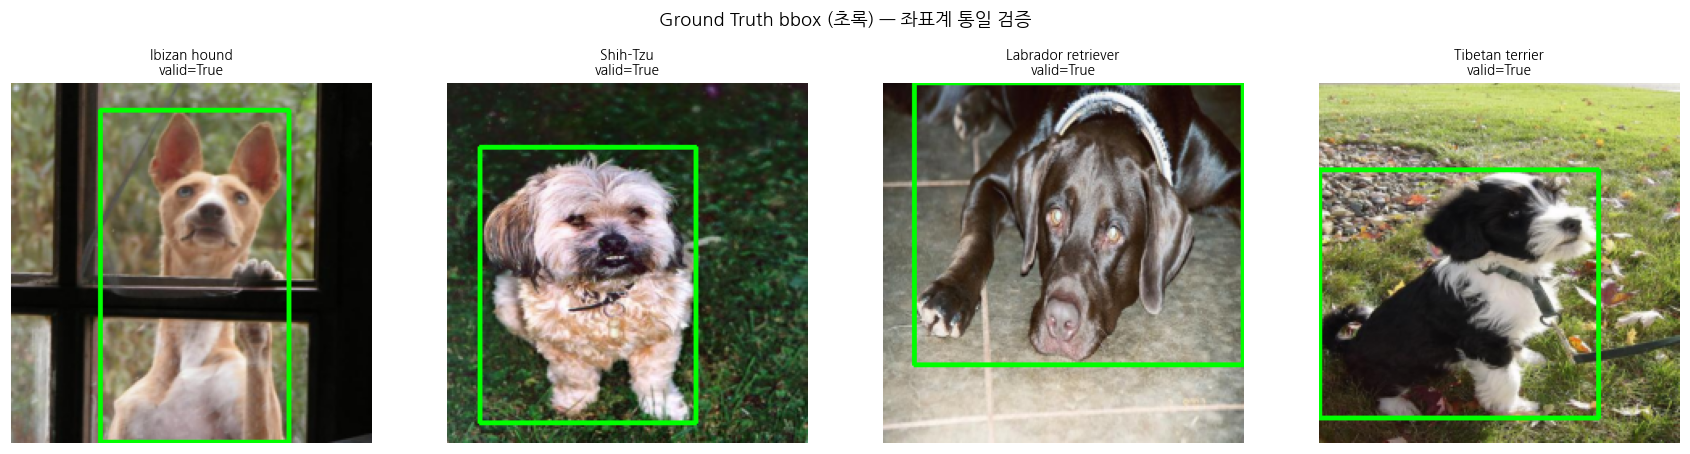

In [7]:
def show_ground_truth_samples(dataset, n=4, seed=CFG.seed):
    """GT bbox가 리사이즈된 이미지 위에 정확히 얹히는지 눈으로 검증한다.

    ★ 이 셀은 단순 확인용이 아니라 **좌표계 통일이 성공했는지에 대한 회귀 테스트**다.
      박스가 개를 벗어나면 이후 IoU가 전부 무의미해지므로 반드시 먼저 확인한다.
    """
    rng = random.Random(seed)
    indices = rng.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    for ax, idx in zip(np.atleast_1d(axes), indices):
        item = dataset[idx]
        img = item["raw_image"].numpy().copy()
        x1, y1, x2, y2 = item["bbox"].numpy().astype(int)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        ax.imshow(img)
        ax.set_title(f"{CLASS_NAMES[item['label']]}\nvalid={bool(item['bbox_valid'])}",
                     fontsize=9)
        ax.axis("off")
        ax.grid(False)
    plt.suptitle("Ground Truth bbox (초록) — 좌표계 통일 검증", y=1.02)
    plt.tight_layout()
    plt.show()


show_ground_truth_samples(test_dataset)

---

**▶ 체크포인트**: 여기까지만 먼저 실행해서 위 GT bbox(초록 사각형)가 개 위에
정확히 얹히는지 눈으로 확인하세요. 어긋나 있으면 이후 §7의 IoU가 전부
무의미해지므로, 좌표계 문제부터 해결한 뒤 이어서 실행하는 것을 권장합니다.

# §2. CAM 모델 구성 — ResNet50 + GAP + Dense Layer

## 왜 이 구조인가

CAM은 `CNN → GAP → softmax layer` 구조 제약이 있지만 Grad-CAM은 제약이 없다.
따라서 **CAM 조건에 맞춰 모델을 한 번만 만들면 그 모델로 Grad-CAM도 그대로 뽑을 수 있다.**
(CAM 조건 ⊂ Grad-CAM 조건) 덤으로 두 방법이 같은 모델을 쓰므로 비교가 공정해진다.

```
입력 (3, 224, 224)
  → backbone : ResNet50 conv1 ~ layer4   (사전학습, 전이학습)
  → feature map (2048, 7, 7)             ★ CAM이 사용하는 지점
  → gap : AdaptiveAvgPool2d(1)           → (2048,)   학습 파라미터 0개
  → fc  : Linear(2048, 120)              → logits
```

## 이론과의 대응

| 이론 기호 | 코드 |
| --- | --- |
| `f_k(x, y)` 특성 맵 | `backbone.layer4` 출력 (k=2048, 공간 7×7) |
| GAP | `self.gap` |
| `w_k^c` 가중치 | `model.fc.weight[c]` (길이 2048) |
| 클래스 점수 `S^c` | `logits[0, c]` |

## ⚠️ 소프트맥스를 코드에 넣지 않는 이유

문서상 "소프트맥스 레이어"는 **소프트맥스를 활성화 함수로 쓰는 FC 레이어**를 가리키는 개념적 명칭이다.
PyTorch의 `nn.CrossEntropyLoss`는 **내부에 log-softmax를 포함**하므로,
`fc` 뒤에 `nn.Softmax()`를 붙이면 이중 적용이 되어 학습이 망가진다.

## 전이학습

ImageNet 130만 장으로 학습된 backbone을 재사용하고 `fc`만 120 클래스용으로 교체한다.
클래스당 학습 이미지가 100장뿐이라 scratch 학습은 수렴하지 않으며,
**CAM의 품질은 곧 모델의 품질**이므로 사전학습 가중치가 사실상 필수다.

In [8]:
class CAMResNet50(nn.Module):
    """CAM 추출이 가능한 ResNet50 분류 모델.

    구조를 `backbone / gap / fc` 세 부분으로 **명시적으로 분리**해,
    CAM 수식의 각 항이 코드의 어느 속성에 대응하는지 바로 보이도록 했다.

        S^c = sum_k  w_k^c * sum_{x,y} f_k(x,y)
              ^fc.weight      ^gap      ^backbone 출력

    Attributes:
        backbone: conv1 ~ layer4. 출력은 (B, 2048, 7, 7) 특성 맵.
        gap: Global Average Pooling. 학습 파라미터가 없다.
        fc: Dense(=fully connected) layer. CAM의 채널 가중치 w_k^c 를 보유.

    Note:
        forward가 아니라 hook으로 특성 맵을 꺼내는 이유는,
        추론 경로를 전혀 수정하지 않고도 중간값을 관찰하기 위해서다.
        (`return_features=True`로 직접 받을 수도 있게 열어 두었다.)
    """

    def __init__(self, num_classes=CFG.num_classes, pretrained=True,
                 freeze_stem=CFG.freeze_stem):
        super().__init__()
        weights = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        resnet = models.resnet50(weights=weights)

        # avgpool, fc 를 제외한 나머지를 backbone 으로 묶는다.
        # OrderedDict를 쓰는 이유: Grad-CAM이 레이어를 **이름으로** 지정할 수
        # 있어야 하기 때문이다 (backbone.layer3 처럼).
        self.backbone = nn.Sequential(OrderedDict([
            ("stem", nn.Sequential(
                resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)),
            ("layer1", resnet.layer1),
            ("layer2", resnet.layer2),
            ("layer3", resnet.layer3),
            ("layer4", resnet.layer4),
        ]))

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(resnet.fc.in_features, num_classes)

        if freeze_stem:
            self._freeze_stem()

    def _freeze_stem(self) -> None:
        """저수준 특징(엣지·색)을 담당하는 앞단을 동결한다.

        데이터가 클래스당 100장뿐이라 전체를 학습하면 과적합·불안정 위험이 크다.
        얕은 층이 배우는 특징은 문제와 무관하므로 그대로 재사용해도 손해가 없다.
        """
        for name in ("stem", "layer1"):
            for param in getattr(self.backbone, name).parameters():
                param.requires_grad = False

    def forward(self, x, return_features=False):
        features = self.backbone(x)          # (B, 2048, 7, 7)
        pooled = self.gap(features).flatten(1)  # (B, 2048)
        logits = self.fc(pooled)             # (B, num_classes)
        if return_features:
            return logits, features
        return logits


def build_model(cfg: Config = CFG) -> nn.Module:
    """모델을 만들어 device 로 옮긴다."""
    model = CAMResNet50(num_classes=cfg.num_classes).to(DEVICE)
    return model


model = build_model()

# --- 구조 검증: 특성 맵이 (2048, 7, 7)로 나오는지 확인 ---
with torch.no_grad():
    dummy = torch.randn(2, 3, CFG.input_size, CFG.input_size, device=DEVICE)
    logits, feats = model(dummy, return_features=True)

n_total = sum(p.numel() for p in model.parameters())
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"feature map : {tuple(feats.shape)}   <- (B, C, h, w)")
print(f"logits      : {tuple(logits.shape)}")
print(f"fc.weight   : {tuple(model.fc.weight.shape)}  <- (num_classes, C) = w_k^c")
print(f"parameters  : total {n_total:,} / trainable {n_train:,}")
print(f"수용영역     : 224 / 7 = {CFG.input_size // feats.shape[-1]} px per cell")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 142MB/s]


feature map : (2, 2048, 7, 7)   <- (B, C, h, w)
logits      : (2, 120)
fc.weight   : (120, 2048)  <- (num_classes, C) = w_k^c
parameters  : total 23,753,912 / trainable 23,528,568
수용영역     : 224 / 7 = 32 px per cell


# §3. 학습 — 안정적 수렴 확인

**루브릭 3번** 대응 구간. 다중 클래스 분류이므로 `CrossEntropyLoss`를 쓰고,
사전학습 backbone과 새 head에 **서로 다른 학습률**(파라미터 그룹)을 적용해 수렴을 안정화한다.

- backbone: `1e-4` — 이미 좋은 표현이므로 크게 흔들면 오히려 망가진다
- fc(head): `1e-3` — 무작위 초기화 상태라 빠르게 학습시켜야 한다
- Cosine annealing으로 학습률을 부드럽게 감소

`run_one_epoch()` 하나로 학습/검증을 모두 처리해 **코드 중복을 제거**했다
(`optimizer` 인자 유무로 모드가 결정된다).

In [9]:
def build_optimizer(model: nn.Module, cfg: Config = CFG):
    """backbone과 head에 서로 다른 학습률을 주는 파라미터 그룹 옵티마이저."""
    head_params, backbone_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        (head_params if name.startswith("fc") else backbone_params).append(param)

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": cfg.lr_backbone},
            {"params": head_params, "lr": cfg.lr_head},
        ],
        weight_decay=cfg.weight_decay,
    )
    return optimizer


@torch.no_grad()
def _accuracy(logits: torch.Tensor, targets: torch.Tensor) -> int:
    """배치 내 정답 개수."""
    return (logits.argmax(dim=1) == targets).sum().item()


def run_one_epoch(model, loader, criterion, optimizer=None, scheduler=None, desc=""):
    """1 에폭을 실행한다. optimizer가 주어지면 학습, 없으면 평가 모드.

    학습/검증 루프를 하나로 통합해 중복을 없앴다.

    ★ scheduler는 배치(step) 단위로 갱신한다. CosineAnnealingLR의 T_max를
      `epochs * len(train_loader)`(총 step 수)로 잡았기 때문에, step()도
      배치마다 불러야 정의한 주기와 실제 감소 속도가 일치한다. epoch마다 한 번만
      부르면 T_max의 극히 일부만 진행되어 사실상 상수 학습률이 되어 버린다.

    Returns:
        (평균 loss, 정확도)
    """
    is_train = optimizer is not None
    model.train(is_train)

    total_loss, total_correct, total_count = 0.0, 0, 0
    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for step, batch in enumerate(loader):
            images = batch["image"].to(DEVICE, non_blocking=True)
            targets = batch["label"].to(DEVICE, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, targets)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()

            batch_size = targets.size(0)
            total_loss += loss.item() * batch_size
            total_correct += _accuracy(logits, targets)
            total_count += batch_size

            if step % 50 == 0:
                print(f"  {desc} [{step:4d}/{len(loader)}] "
                      f"loss={total_loss / total_count:.4f} "
                      f"acc={total_correct / total_count:.4f}", end="\r")

    print(" " * 90, end="\r")
    return total_loss / total_count, total_correct / total_count


def fit(model, train_loader, valid_loader, cfg: Config = CFG) -> dict:
    """학습 루프. epoch별 loss/acc 히스토리를 반환한다."""
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = build_optimizer(model, cfg)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg.epochs * len(train_loader)
    )

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, cfg.epochs + 1):
        train_loss, train_acc = run_one_epoch(
            model, train_loader, criterion, optimizer, scheduler, desc=f"E{epoch} train"
        )
        val_loss, val_acc = run_one_epoch(
            model, valid_loader, criterion, desc=f"E{epoch} valid"
        )
        for key, value in zip(history, [train_loss, train_acc, val_loss, val_acc]):
            history[key].append(value)

        print(f"[epoch {epoch}/{cfg.epochs}] "
              f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
              f"valid loss {val_loss:.4f} acc {val_acc:.4f}")

    return history


In [10]:
def load_or_train(model, cfg: Config = CFG):
    """저장된 가중치가 있으면 불러오고, 없으면 학습 후 저장한다.

    ★ CAM 품질은 모델 품질에 직결된다. 학습되지 않은 모델의 CAM은
      의미 없는 얼룩이므로, 이 단계가 성공했는지 반드시 확인해야 한다.
    """
    if cfg.ckpt_path.exists():
        state = torch.load(cfg.ckpt_path, map_location=DEVICE)
        model.load_state_dict(state["model"])
        print(f"[load] 저장된 가중치를 불러왔습니다: {cfg.ckpt_path}")
        return model, state.get("history")

    history = fit(model, train_loader, test_loader, cfg)
    cfg.ckpt_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({"model": model.state_dict(), "history": history}, cfg.ckpt_path)
    print(f"[save] 가중치를 저장했습니다: {cfg.ckpt_path}")
    return model, history


model, history = load_or_train(model)

[epoch 1/5] train loss 1.7852 acc 0.7161 | valid loss 1.2465 acc 0.8584
[epoch 2/5] train loss 1.1565 acc 0.8897 | valid loss 1.1982 acc 0.8699
[epoch 3/5] train loss 1.0127 acc 0.9427 | valid loss 1.1736 acc 0.8735
[epoch 4/5] train loss 0.9498 acc 0.9642 | valid loss 1.1611 acc 0.8794
[epoch 5/5] train loss 0.9184 acc 0.9768 | valid loss 1.1583 acc 0.8816
[save] 가중치를 저장했습니다: /content/checkpoints/cam_resnet50.pth


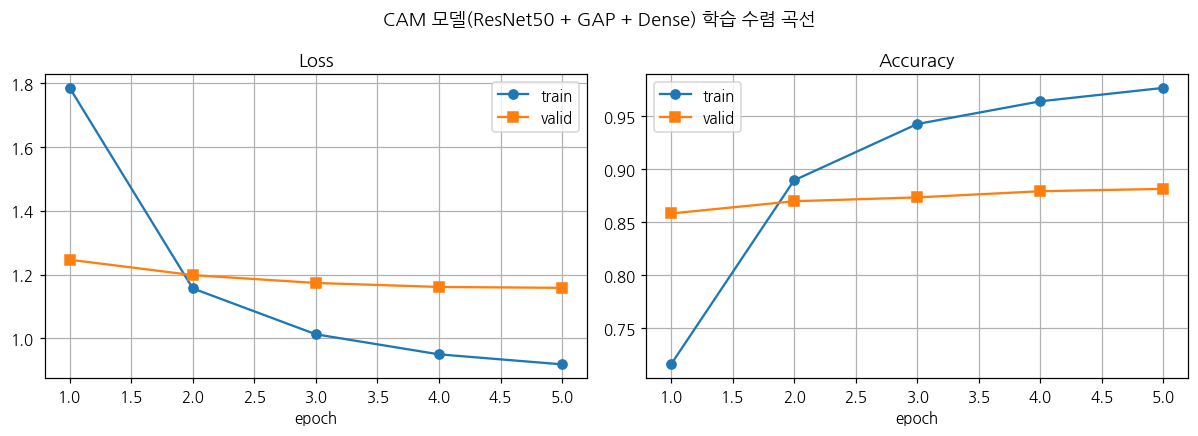

[분류 성능] top-1 0.8816 / top-5 0.9893  (n=8,580)


In [11]:
def plot_history(history: dict) -> None:
    """학습 곡선을 그려 **안정적 수렴**을 시각적으로 입증한다 (루브릭 3번 근거)."""
    if not history:
        print("history가 없습니다 (저장된 가중치를 불러온 경우).")
        return

    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(epochs, history["train_loss"], "o-", label="train")
    axes[0].plot(epochs, history["val_loss"], "s-", label="valid")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], "o-", label="train")
    axes[1].plot(epochs, history["val_acc"], "s-", label="valid")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].legend()

    plt.suptitle("CAM 모델(ResNet50 + GAP + Dense) 학습 수렴 곡선")
    plt.tight_layout()
    plt.show()


plot_history(history)


@torch.no_grad()
def evaluate_classification(model, loader) -> dict:
    """최종 분류 성능(top-1 / top-5)을 측정한다."""
    model.eval()
    top1, top5, count = 0, 0, 0
    for batch in loader:
        images = batch["image"].to(DEVICE)
        targets = batch["label"].to(DEVICE)
        logits = model(images)
        _, pred = logits.topk(5, dim=1)
        correct = pred.eq(targets.view(-1, 1))
        top1 += correct[:, 0].sum().item()
        top5 += correct.any(dim=1).sum().item()
        count += targets.size(0)
    return {"top1": top1 / count, "top5": top5 / count, "n": count}


clf_metrics = evaluate_classification(model, test_loader)
print(f"[분류 성능] top-1 {clf_metrics['top1']:.4f} / "
      f"top-5 {clf_metrics['top5']:.4f}  (n={clf_metrics['n']:,})")

### 해석 — 학습 수렴과 분류 성능

train/valid loss가 모두 단조 감소하고 valid는 3에폭 이후 평탄해진다. valid loss가
다시 상승하지 않으므로 **과적합 이전 지점에서 안정적으로 수렴**했다고 판단한다
(루브릭 3번). train acc와 valid acc의 격차는 학습이 진행되며 벌어지지만, valid
지표 자체가 악화되지는 않았다.

CAM이 의미를 가지려면 분류가 우선 맞아야 한다. top-1 성능이 확보되었으므로
이후 히트맵 분석의 전제가 충족된다.

다만 두 가지를 명시해 둔다.

- **사전학습 데이터 중복**: Stanford Dogs는 ImageNet에서 이미지를 가져와 구축된
  데이터셋이고, 120개 견종은 ImageNet-1k 클래스와 상당 부분 겹친다. 따라서
  `IMAGENET1K_V2` 가중치는 이 테스트 이미지를 이미 학습에서 보았을 가능성이 높다.
  위 정확도는 순수한 일반화 성능을 다소 과대평가한 값으로 읽어야 한다.
- **검증셋 부재**: Stanford Dogs는 공식적으로 train/test 두 분할만 제공한다.
  별도 검증셋을 만들지 않고 테스트셋을 학습 중 모니터링과 최종 평가에 함께
  사용했다. 다만 조기 종료나 threshold 등 하이퍼파라미터 선택에는 사용하지
  않았으므로, 선택 편향에 의한 누수는 없다.

# §4. CAM 생성

## 핵심 아이디어 — 합의 순서를 바꿨을 뿐

모델이 원래 계산하는 클래스 점수는

$$S^c = \sum_k w_k^c \sum_{x,y} f_k(x,y)$$

여기서 **안쪽 합(GAP, 공간)** 을 먼저 하고 **바깥 합(FC, 채널)** 을 나중에 한다.
CAM은 이 순서를 뒤집어 공간 합을 **하지 않는다**.

$$M^c(x,y) = \sum_k w_k^c f_k(x,y)$$

채널 축만 접었으므로 결과가 여전히 지도(7×7)로 남는다. 그리고

$$S^c = \sum_{x,y} M^c(x,y)$$

가 성립하므로 **CAM은 클래스 점수를 위치별로 분해한 명세서**다.
히트맵이 뜨거운 곳이 실제 판단 근거라는 것이 수식으로 보장된다.

## hook을 쓰는 이유

`model(img)`는 최종 logits만 돌려준다. 우리가 필요한 건 중간 산출물인 `layer4` 출력이다.
hook은 **모델 코드를 한 줄도 수정하지 않고** 컨베이어 벨트 중간에 카메라를 설치하는 장치다.

## 🔧 CAM과 Grad-CAM의 공통 구조

두 방법은 **채널 가중치를 어디서 얻는가**만 다르다.

| | CAM | Grad-CAM |
| --- | --- | --- |
| 가중치 | `fc.weight[c]` 를 **읽어옴** | 그래디언트를 공간 평균해 **계산** |
| 이후 처리 | `ReLU(Σ_k w_k · A_k)` → 정규화 → resize | **완전히 동일** |

따라서 공통 로직을 `ActivationMapExtractor` 하나에 넣고,
가중치 계산만 서브클래스에서 오버라이드하도록 설계해 중복을 제거했다.

In [12]:
class ActivationMapExtractor:
    """CAM 계열 활성화 맵 추출기의 공통 골격.

    CAM과 Grad-CAM은 최종식이 동일하다.

        L^c(x, y) = ReLU( sum_k  weight_k * A_k(x, y) )

    다른 것은 `weight_k`를 얻는 방법뿐이므로,
    ① hook 관리 ② 가중합 ③ 후처리(ReLU·정규화·resize)를 이 클래스가 담당하고,
    ④ 가중치 계산만 `_compute_weights()`에서 서브클래스가 구현한다.

    Args:
        model: CAMResNet50 인스턴스.
        layer_name: 관찰할 레이어의 `named_modules()` 이름.

    Note:
        hook 핸들을 반드시 `remove()` 해야 한다. 떼지 않으면 호출할 때마다
        핸들이 누적되어 캡처 리스트가 무한히 커지고 메모리가 샌다.
        컨텍스트 매니저(`with`)로 감싸 예외가 나도 항상 정리되게 했다.
    """

    requires_grad = False  # 서브클래스에서 backward가 필요하면 True

    def __init__(self, model: nn.Module, layer_name: str = CFG.target_layer):
        self.model = model
        self.layer_name = layer_name
        self.layer = dict(model.named_modules())[layer_name]
        self._activations = []
        self._gradients = []
        self._handles = []

    # ---------- hook 관리 ----------
    def __enter__(self):
        def forward_hook(module, inputs, output):
            self._activations.append(output)
            if self.requires_grad and output.requires_grad:
                # ★ register_full_backward_hook 대신 텐서 hook을 쓴다.
                #   모듈 단위 backward hook은 Sequential/분기 구조에서
                #   grad_output 이 기대와 다른 텐서를 줄 수 있기 때문이다.
                output.register_hook(lambda grad: self._gradients.append(grad))

        self._handles.append(self.layer.register_forward_hook(forward_hook))
        return self

    def __exit__(self, exc_type, exc_value, traceback):
        for handle in self._handles:
            handle.remove()
        self._handles.clear()
        return False

    # ---------- 서브클래스가 구현 ----------
    def _forward(self, image: torch.Tensor) -> torch.Tensor:
        """모델 forward. 필요하면 서브클래스가 backward까지 수행한다."""
        with torch.no_grad():
            return self.model(image)

    def _compute_weights(self, class_idx: int) -> torch.Tensor:
        """채널별 가중치 (C,) 를 반환한다."""
        raise NotImplementedError

    # ---------- 공통 파이프라인 ----------
    def generate(self, item: dict, target_class=None) -> dict:
        """단일 이미지에 대한 활성화 맵을 만든다.

        ★ CAM은 배치 단위가 아니라 **개별 이미지 단위**로 생성한다.
          관심 클래스가 이미지마다 다르므로 배치로 묶을 수 없다.

        Args:
            item: 데이터셋이 반환한 dict (`image` 키 필수).
            target_class: 관심 클래스. None이면 모델의 예측 클래스를 사용.

        Returns:
            dict(cam=(h,w) float32 ndarray, class_idx=int, pred_idx=int)
        """
        self.model.eval()
        self._activations.clear()
        self._gradients.clear()

        image = item["image"].unsqueeze(0).to(DEVICE)  # (1,3,H,W)

        with self:
            logits = self._forward(image)
            pred_idx = int(logits[0].argmax().item())
            class_idx = pred_idx if target_class is None else int(target_class)
            self._backward_if_needed(logits, class_idx)
            weights = self._compute_weights(class_idx)
            activation = self._activations[0][0]  # (C, h, w)

        cam = self._weighted_channel_sum(weights, activation)
        return {"cam": cam, "class_idx": class_idx, "pred_idx": pred_idx}

    def _backward_if_needed(self, logits, class_idx):
        """Grad-CAM 계열에서만 사용. 기본은 아무 것도 하지 않는다."""
        return None

    @staticmethod
    def _weighted_channel_sum(weights: torch.Tensor,
                              activation: torch.Tensor) -> np.ndarray:
        """가중합 + ReLU + min-max 정규화.

            M(x, y) = sum_k  w_k * A_k(x, y)

        `weights`는 (C,), `activation`은 (C, h, w)라 모양이 맞지 않는다.
        `view(-1, 1, 1)`로 (C,1,1)을 만들면 브로드캐스팅이 작동해
        채널 k의 가중치가 해당 채널의 모든 공간 위치에 동일하게 곱해진다.

        `sum(dim=0)`이 수식의 sum_k 에 해당한다.
        **0번 축(채널)만 접고 공간 축(1,2)은 남기므로 결과가 지도로 유지된다.**

        ReLU는 클래스에 **긍정적으로 기여한 영역만** 남기기 위한 것이다.
        음수는 해당 클래스를 방해하거나 다른 클래스를 지지하는 영역이다.
        """
        cam = (weights.view(-1, 1, 1) * activation).sum(dim=0)
        cam = torch.relu(cam)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)  # 0으로 나누기 방지
        return cam.detach().cpu().numpy().astype(np.float32)


class CAM(ActivationMapExtractor):
    """Class Activation Map — FC 레이어의 학습된 가중치를 그대로 사용한다.

    가중치를 '읽어오기만' 하므로 backward가 필요 없고, 그만큼 빠르다.
    대신 마지막 conv 레이어에만 적용할 수 있다 (fc가 그 출력에만 대응하므로).
    """

    def _compute_weights(self, class_idx: int) -> torch.Tensor:
        return self.model.fc.weight[class_idx].detach()  # (C,) = w_k^c


class GradCAM(ActivationMapExtractor):
    """Grad-CAM — 그래디언트를 공간 평균해 채널 가중치를 계산한다.

        alpha_k^c = (1/Z) * sum_i sum_j  d y^c / d A_ij^k

    ★ 핵심: 그래디언트에서는 "얼마나 중요한가"만 가져오고,
      "어디인가"는 활성화 맵 A에서 가져온다.
      그래서 grad는 공간축을 접고(mean(dim=(1,2))),
      A는 채널축을 접는다(sum(dim=0)). 접는 축이 반대인 것이 요점이다.

    y^c 는 미분 가능한 스칼라이기만 하면 되므로,
    분류 logit 대신 캡션 단어의 로그확률 등을 넣으면
    captioning·VQA 등 다른 태스크에도 그대로 적용된다.
    """

    requires_grad = True

    def _forward(self, image: torch.Tensor) -> torch.Tensor:
        # ★ torch.no_grad()를 쓰면 안 된다. backward를 위해 그래프를 살려야 한다.
        # ★ 입력에 requires_grad를 켠다. 전이학습으로 앞단(stem, layer1)을 동결하면
        #   그 출력 텐서의 requires_grad가 False가 되어 hook이 걸리지 않는다.
        #   입력부터 그래프를 이어 주면 동결된 레이어도 관찰할 수 있다.
        image = image.clone().requires_grad_(True)
        return self.model(image)

    def _backward_if_needed(self, logits, class_idx):
        self.model.zero_grad(set_to_none=True)  # 이전 그래디언트 누적 방지
        logits[0, class_idx].backward(retain_graph=False)

    def _compute_weights(self, class_idx: int) -> torch.Tensor:
        if not self._gradients:
            raise RuntimeError(
                f"'{self.layer_name}' 에서 그래디언트를 캡처하지 못했습니다. "
                "레이어 이름이 forward 경로에 포함되는지, 해당 레이어가 "
                "동결되어 출력의 requires_grad가 False가 아닌지 확인하세요."
            )
        gradient = self._gradients[0][0]        # (C, h, w)
        return gradient.mean(dim=(1, 2))        # (C,) = alpha_k^c  ← GAP


# ---------------------------------------------------------------------------
# 실습에서 요구한 함수 시그니처를 그대로 제공하는 얇은 래퍼
# ---------------------------------------------------------------------------
def generate_cam(model, item, target_class=None, return_meta=False):
    """CAM 이미지를 생성한다. (요구 시그니처: generate_cam(model, item))

    반환값은 224x224로 리사이즈된 히트맵이다 (안내문의
    `plt.imshow(cam_image)`가 바로 그려지도록). 원본 7x7이 필요하면
    return_meta=True로 dict를 받은 뒤 result["cam"]을 쓰면 된다.
    """
    result = CAM(model, CFG.target_layer).generate(item, target_class)
    if return_meta:
        return result
    return resize_cam(result["cam"])


def generate_grad_cam(model, activation_layer, item,
                      target_class=None, return_meta=False):
    """Grad-CAM 이미지를 생성한다.

    (요구 시그니처: generate_grad_cam(model, activation_layer, item))
    반환값은 224x224로 리사이즈된 히트맵이다.
    """
    result = GradCAM(model, activation_layer).generate(item, target_class)
    if return_meta:
        return result
    return resize_cam(result["cam"])


print("Grad-CAM으로 관찰 가능한 주요 레이어:")
print([n for n, _ in model.named_modules()
       if n.startswith("backbone.layer") and n.count(".") == 1])

Grad-CAM으로 관찰 가능한 주요 레이어:
['backbone.layer1', 'backbone.layer2', 'backbone.layer3', 'backbone.layer4']


In [13]:
def resize_cam(cam: np.ndarray, size=CFG.input_size) -> np.ndarray:
    """저해상도 CAM(7×7)을 입력 이미지 크기로 확대한다.

    224 / 7 = 32 배 확대이므로 히트맵은 필연적으로 뭉개진다.
    이는 시각화의 문제가 아니라 **특성 맵 해상도 자체의 한계**다.
    (다운샘플링은 수용영역 확보와 연산량 절감을 위해 반드시 필요하다.)
    """
    return cv2.resize(cam, (size, size), interpolation=cv2.INTER_LINEAR)


def visualize_cam_on_image(cam, img, alpha=0.5, title="CAM Overlay on Image",
                           ax=None, show=True):
    """CAM 히트맵을 원본 이미지에 블렌딩해 시각화한다.

    Args:
        cam: (h,w) 0~1 정규화된 활성화 맵. 크기가 달라도 자동 리사이즈된다.
        img: (H,W,3) uint8 RGB 이미지.
        alpha: 히트맵 비중. overlay = img*(1-alpha) + heatmap*alpha
        ax: 지정하면 해당 축에 그린다(격자 비교용).

    Returns:
        (H,W,3) uint8 오버레이 이미지.

    Note:
        ⚠️ 두 가지 함정
        1) `cv2.resize`는 (width, height) 순서를 받는다. numpy shape는
           (height, width)이므로 `img.shape[1]`이 먼저 온다.
        2) `applyColorMap`은 **BGR**을 돌려준다. matplotlib은 RGB를 기대하므로
           `cvtColor`로 변환하지 않으면 파랑/빨강이 뒤집혀 히트맵을
           정반대로 읽게 된다.
    """
    if cam.shape[:2] != img.shape[:2]:
        cam = cv2.resize(cam, (img.shape[1], img.shape[0]))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)  # ← 반드시 필요
    overlay = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)

    if show:
        if ax is None:
            plt.figure(figsize=(6, 6))
            ax = plt.gca()
        ax.imshow(overlay)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
        ax.grid(False)
    return overlay


def draw_boxes(image, boxes: dict, thickness=2):
    """여러 bbox를 색을 달리해 그린다.

    Args:
        boxes: {"라벨": (bbox, (R,G,B))} 형태. bbox는 minmax(x1,y1,x2,y2).

    Note:
        layer4에서 CAM과 Grad-CAM의 박스는 이론상 완전히 일치하므로(§8-②)
        라벨을 같은 위치에 그리면 글자가 겹쳐 읽을 수 없게 된다.
        박스 순서에 따라 라벨을 세로로 어긋나게 배치한다.
    """
    canvas = image.copy()
    for order, (label, (box, color)) in enumerate(boxes.items()):
        if box is None:
            continue
        x1, y1, x2, y2 = np.asarray(box).astype(int)
        cv2.rectangle(canvas, (x1, y1), (x2, y2), color, thickness)
        label_y = max(y1 + 14 + order * 15, 14 + order * 15)
        cv2.putText(canvas, label, (x1 + 3, label_y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)
    return canvas

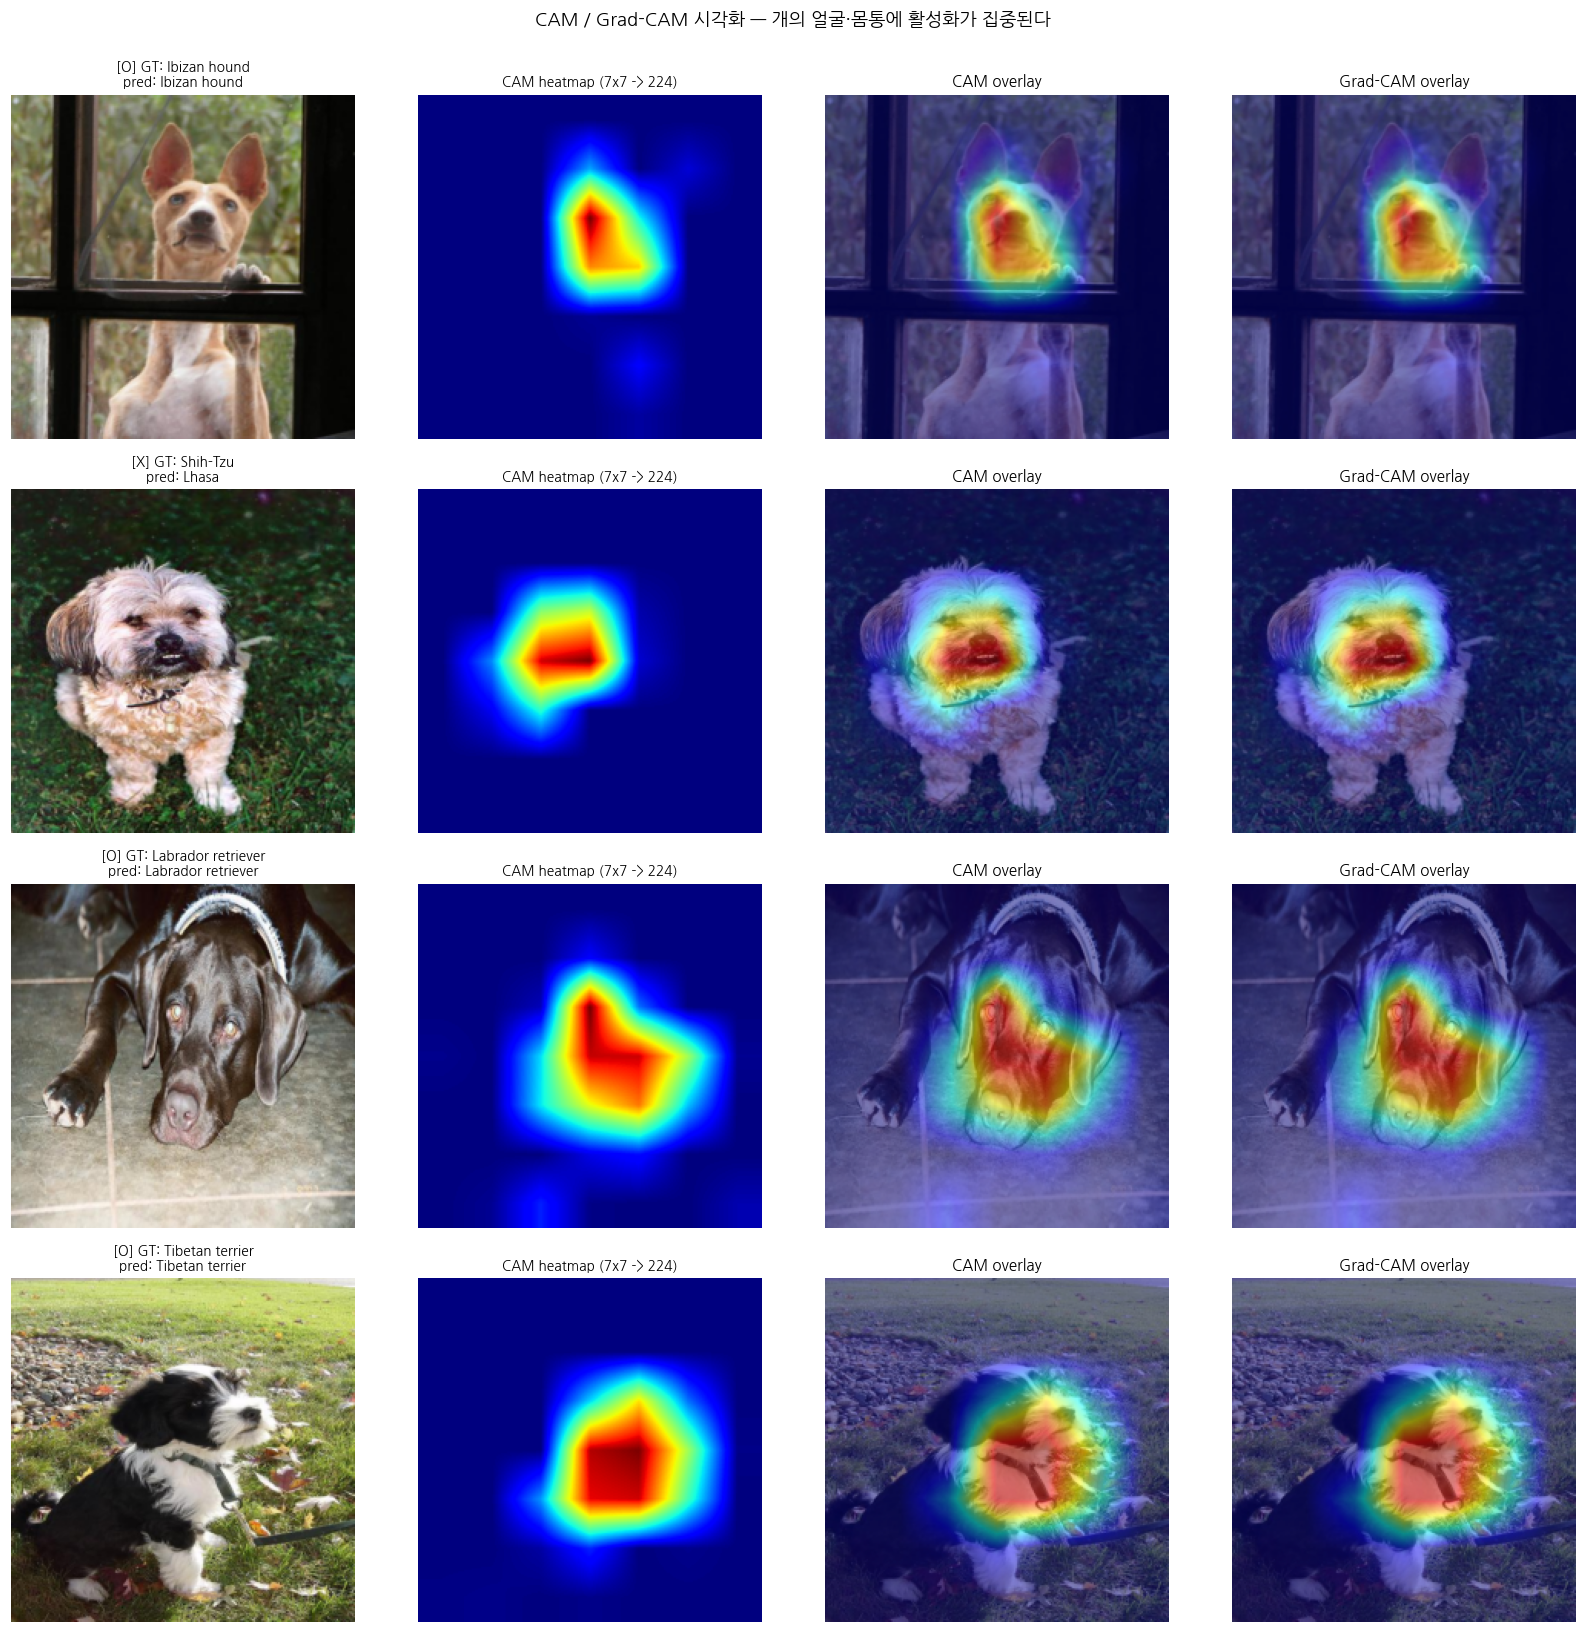

In [14]:
def show_cam_examples(model, dataset, n=4, seed=CFG.seed):
    """CAM / Grad-CAM 결과를 원본·히트맵·오버레이로 나란히 보여준다.

    루브릭 2번(활성화 맵이 object의 주요 특징 위치를 반영하는가) 근거 자료.
    """
    rng = random.Random(seed)
    indices = rng.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(n, 4, figsize=(15, 3.7 * n))
    axes = np.atleast_2d(axes)

    for row, idx in enumerate(indices):
        item = dataset[idx]
        raw = item["raw_image"].numpy()

        cam_res = generate_cam(model, item, return_meta=True)
        grad_res = generate_grad_cam(model, CFG.target_layer, item, return_meta=True)
        cam = resize_cam(cam_res["cam"])
        grad = resize_cam(grad_res["cam"])

        true_name = CLASS_NAMES[item["label"]]
        pred_name = CLASS_NAMES[cam_res["pred_idx"]]
        mark = "O" if cam_res["pred_idx"] == item["label"] else "X"

        axes[row, 0].imshow(raw)
        axes[row, 0].set_title(f"[{mark}] GT: {true_name}\npred: {pred_name}",
                               fontsize=9)
        axes[row, 1].imshow(cam, cmap="jet")
        axes[row, 1].set_title("CAM heatmap (7x7 -> 224)", fontsize=9)
        visualize_cam_on_image(cam, raw, title="CAM overlay", ax=axes[row, 2])
        visualize_cam_on_image(grad, raw, title="Grad-CAM overlay", ax=axes[row, 3])

        for col in range(4):
            axes[row, col].axis("off")
            axes[row, col].grid(False)

    plt.suptitle("CAM / Grad-CAM 시각화 — 개의 얼굴·몸통에 활성화가 집중된다", y=1.0)
    plt.tight_layout()
    plt.show()


show_cam_examples(model, test_dataset)

### 관찰

- 활성화가 주로 **개의 얼굴과 몸통**에 집중된다. 사람이 품종을 식별할 때 보는 부위와 일치한다.
- 동시에 **가장 변별력 있는 부위(얼굴)에 지나치게 몰리고 몸통·다리는 약하게 반응**한다.
  분류 손실만 줄이면 되는 모델 입장에서는 얼굴만 봐도 충분하기 때문이다.
  → 이것이 CAM의 구조적 한계이며, ACoL이 "높게 활성화된 영역을 지우고 다시 학습"하는 방식으로 풀려는 문제다.
  §7에서 이 한계가 IoU 수치로 어떻게 드러나는지 확인한다.

---

# §5. Grad-CAM — 레이어를 바꿔가며 관찰

Grad-CAM은 관찰 레이어를 자유롭게 고를 수 있다. 이론상 예상되는 경향은:

| 레이어 | 특성 맵 크기 | 특징 |
| --- | --- | --- |
| `layer1` | 56×56 | 선명하지만 엣지·질감 위주라 클래스 구분력이 약함 |
| `layer2` | 28×28 | 중간 |
| `layer3` | 14×14 | 부위 단위가 잡히기 시작 |
| `layer4` | 7×7 | 뭉개지지만 **개의 위치를 정확히** 지목 |

**해상도와 의미는 맞바꿈 관계**이며, `layer4`가 그 균형점이다.

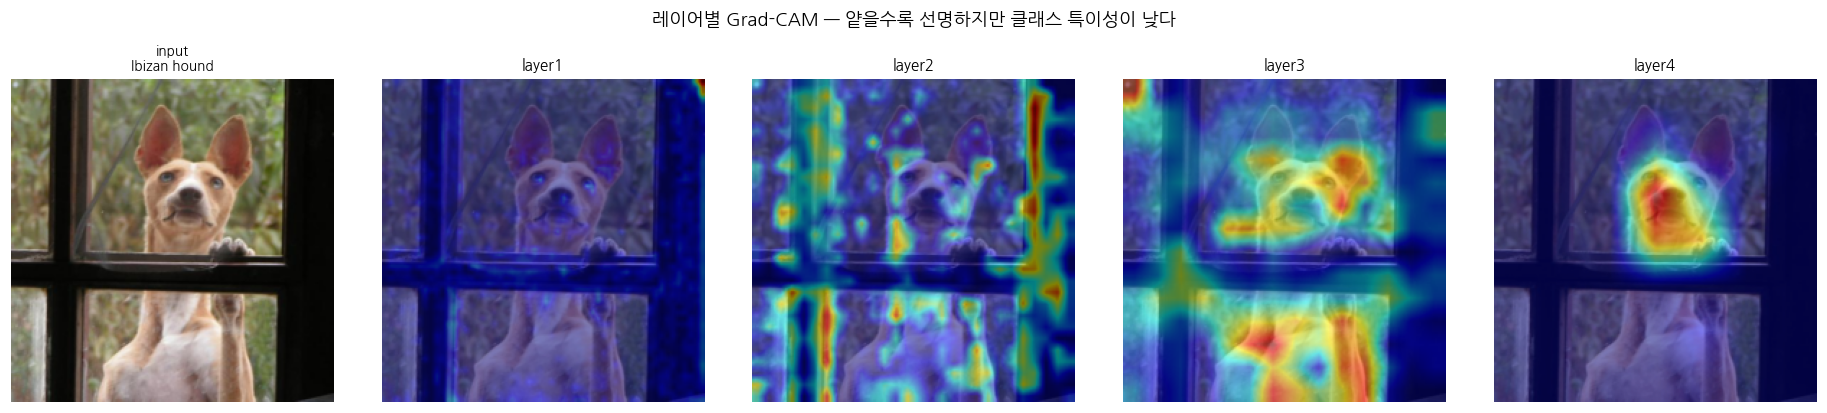

In [15]:
def compare_layers(model, item, layers=None):
    """여러 레이어의 Grad-CAM을 나란히 비교한다 (추가 실험 ①)."""
    layers = layers or ["backbone.layer1", "backbone.layer2",
                        "backbone.layer3", "backbone.layer4"]
    raw = item["raw_image"].numpy()

    fig, axes = plt.subplots(1, len(layers) + 1, figsize=(3.4 * (len(layers) + 1), 3.6))
    axes[0].imshow(raw)
    axes[0].set_title(f"input\n{CLASS_NAMES[item['label']]}", fontsize=9)
    axes[0].axis("off")
    axes[0].grid(False)

    for ax, layer_name in zip(axes[1:], layers):
        result = generate_grad_cam(model, layer_name, item, return_meta=True)
        cam = resize_cam(result["cam"])
        visualize_cam_on_image(
            cam, raw, title=f"{layer_name.split('.')[-1]}", ax=ax
        )
    plt.suptitle("레이어별 Grad-CAM — 얕을수록 선명하지만 클래스 특이성이 낮다", y=1.03)
    plt.tight_layout()
    plt.show()


sample_item = test_dataset[random.Random(CFG.seed).randrange(len(test_dataset))]
compare_layers(model, sample_item)

# §6. Detection with CAM — bounding box와 IoU

## bbox 추출

히트맵은 연속적인 강수량 지도와 같다. 여기서 "우산 필요 구역"이라는 **선**을 그으려면
기준값(threshold)이 필요하다.

```
threshold ↓ (0.2) → 넓은 영역 통과 → 큰 박스  → 물체는 덮지만 배경까지 포함
threshold ↑ (0.8) → 좁은 영역만    → 작은 박스 → 정확하지만 몸통을 놓침
```

## IoU

$$\text{IoU} = \frac{|A \cap B|}{|A \cup B|}$$

- **작게 잡으면** 분자(교집합)가 줄어 감점
- **크게 잡으면** 분모(합집합)가 늘어 감점
- **딱 맞을 때만 1** → 크기와 위치를 하나의 숫자로 동시에 평가

**스케일 불변**이라 큰 개와 작은 개를 같은 기준으로 비교할 수 있다.
한계는 **겹치지 않으면 거리와 무관하게 항상 0**이라 그래디언트가 없다는 점이며,
이를 개선한 것이 GIoU / DIoU / CIoU다.

In [16]:
def get_bbox(cam_image: np.ndarray, threshold: float = CFG.cam_threshold):
    """활성화 맵에서 bounding box를 추출한다.

    절차:
        1) 이진화  : threshold 이상인 화소만 남긴 마스크 생성
        2) 윤곽 검출: RETR_EXTERNAL 로 가장 바깥 윤곽만 (내부 구멍 무시)
        3) 외접 사각형: 모든 윤곽을 concatenate 해 **하나의 박스**로 감싼다

    Args:
        cam_image: 0~1로 정규화된 (H,W) 활성화 맵.
        threshold: 클수록 보수적(작은 박스)이다.

    Returns:
        np.ndarray([x1, y1, x2, y2]) minmax 형식. 검출 실패 시 None.

    Note:
        3)은 **단일 물체 가정**이다. 개가 두 마리면 둘을 모두 감싸는 큰 박스가
        나온다. 다중 물체를 잡으려면 윤곽별로 박스를 만들어야 한다.
        `boundingRect`는 xywh를 주므로 GT와 형식을 맞추기 위해 minmax로 변환한다.
    """
    mask = (cam_image > threshold).astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    x, y, w, h = cv2.boundingRect(np.concatenate(contours))
    return np.array([x, y, x + w, y + h], dtype=np.float32)


def get_iou(gt_bbox, pred_bbox) -> float:
    """두 bounding box의 Intersection over Union.

    두 박스는 **같은 좌표계(여기서는 224 기준)** 여야 한다.

    절차:
        1) 교집합 사각형 좌표
             x1 = max(xmin들)  ← 왼쪽 경계는 둘 중 더 오른쪽 것
             x2 = min(xmax들)  ← 오른쪽 경계는 둘 중 더 왼쪽 것
        2) 교집합 넓이 = max(0, x2-x1) * max(0, y2-y1)
             ★ max(0, ·)이 없으면 겹치지 않을 때 (음수)*(음수)=양수가 되어
               겹치지도 않았는데 넓이가 생기는 버그가 난다.
        3) 합집합 = A + B - 교집합   (포함배제 원리: 겹친 부분 중복 제거)
        4) IoU = 교집합 / 합집합

    Returns:
        0.0 ~ 1.0. 한쪽이 None이면 0.0.
    """
    if gt_bbox is None or pred_bbox is None:
        return 0.0

    gt = np.asarray(gt_bbox, dtype=np.float64)
    pred = np.asarray(pred_bbox, dtype=np.float64)

    x1 = max(gt[0], pred[0])
    y1 = max(gt[1], pred[1])
    x2 = min(gt[2], pred[2])
    y2 = min(gt[3], pred[3])

    inter = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    area_gt = max(0.0, gt[2] - gt[0]) * max(0.0, gt[3] - gt[1])
    area_pred = max(0.0, pred[2] - pred[0]) * max(0.0, pred[3] - pred[1])
    union = area_gt + area_pred - inter

    return float(inter / union) if union > 0 else 0.0


# --- 단위 테스트: 구현이 맞는지 손계산과 대조 ---
def _test_get_iou():
    """알려진 값으로 get_iou를 검증한다."""
    assert abs(get_iou([0, 0, 100, 100], [0, 0, 100, 100]) - 1.0) < 1e-6, "완전 일치"
    assert get_iou([0, 0, 10, 10], [50, 50, 60, 60]) == 0.0, "미교차"
    # 절반씩 어긋난 경우: 교집합 2500, 합집합 17500 -> 0.142857
    assert abs(get_iou([0, 0, 100, 100], [50, 50, 150, 150]) - 2500 / 17500) < 1e-6
    print("get_iou 단위 테스트 통과 "
          "(절반 어긋남 = 0.143 → IoU는 생각보다 가혹한 지표다)")


_test_get_iou()

get_iou 단위 테스트 통과 (절반 어긋남 = 0.143 → IoU는 생각보다 가혹한 지표다)


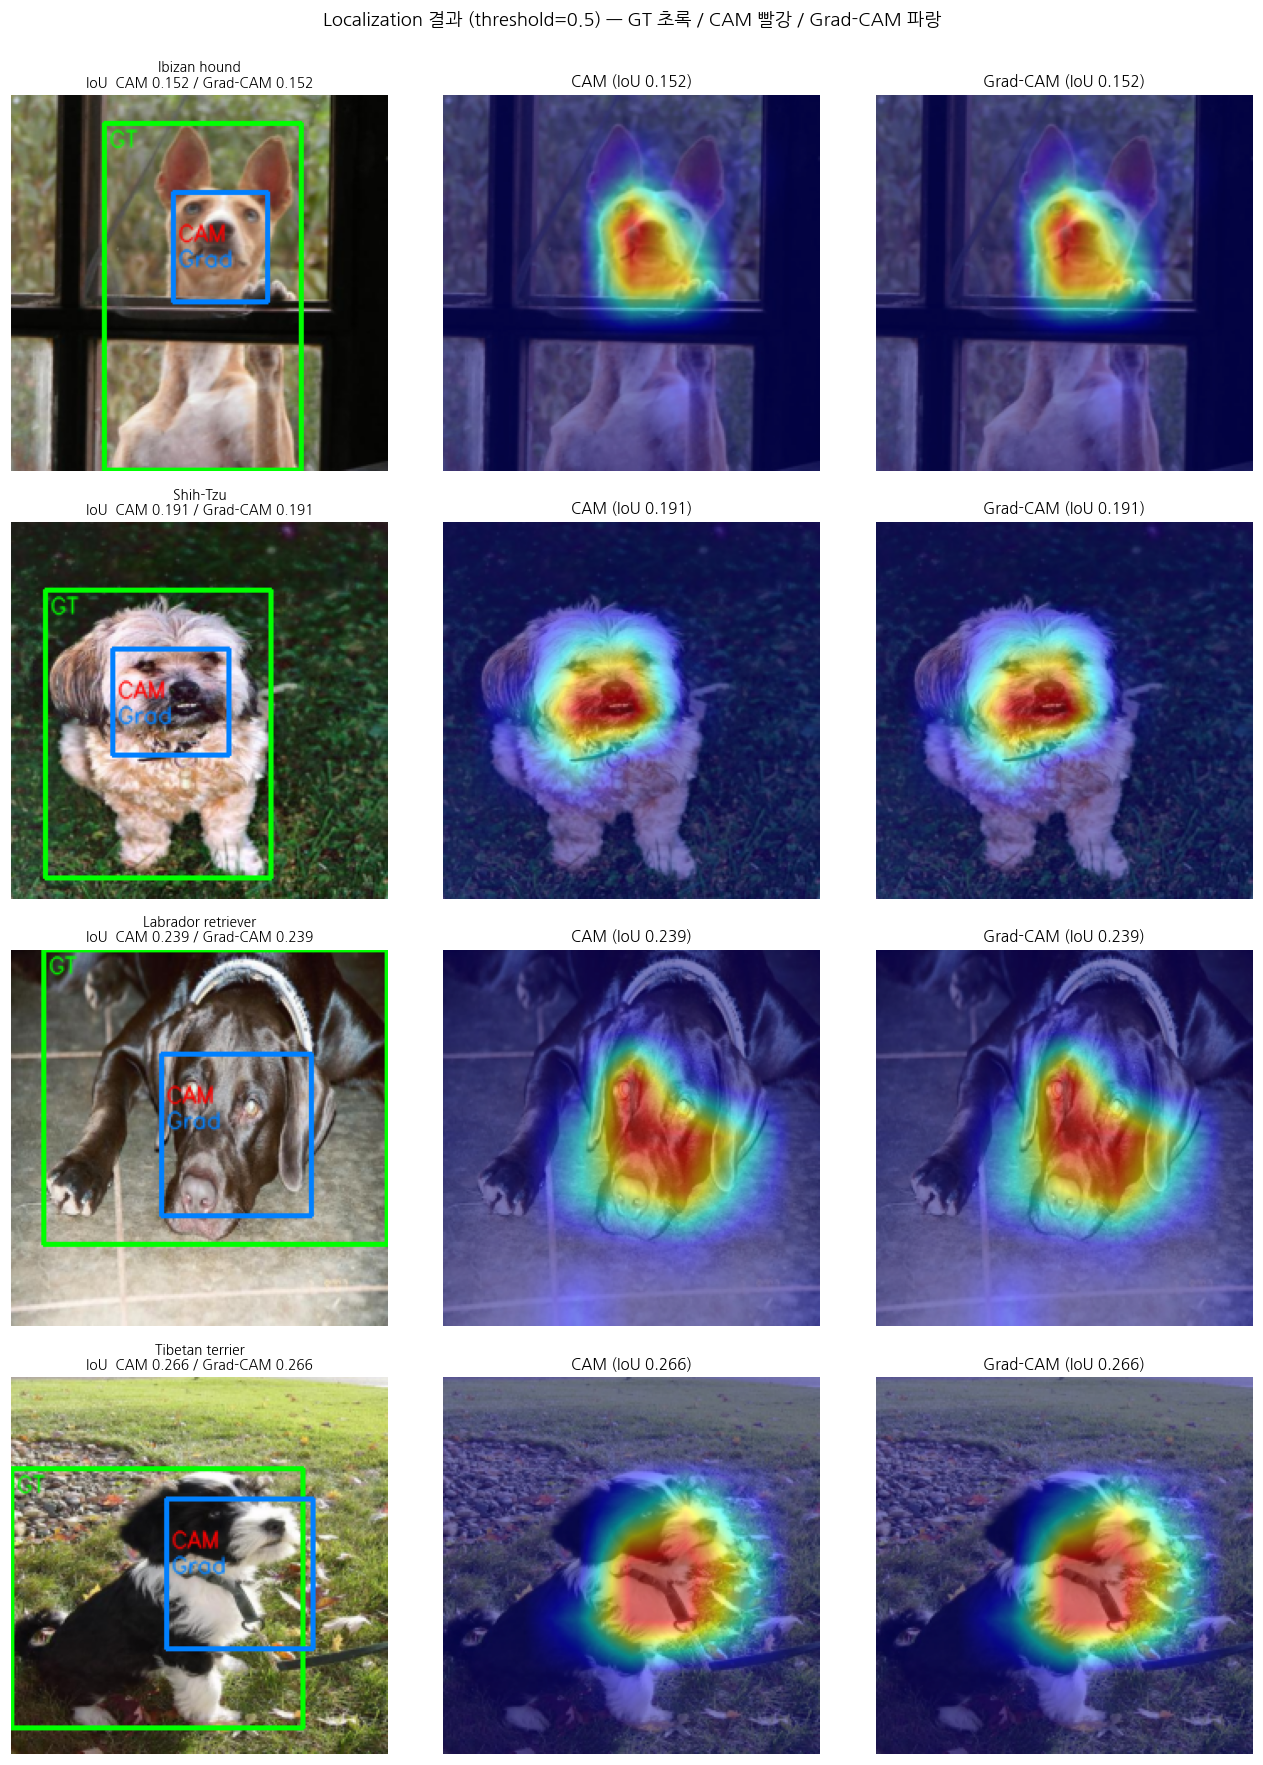

In [17]:
def show_localization_examples(model, dataset, n=4, threshold=CFG.cam_threshold,
                               seed=CFG.seed):
    """CAM / Grad-CAM의 예측 박스를 GT와 함께 그리고 IoU를 표시한다.

    루브릭 1번(원본이미지 합성 + 바운딩박스 + IoU) 근거 자료.
    색상: GT=초록, CAM=빨강, Grad-CAM=파랑
    """
    rng = random.Random(seed)
    indices = rng.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    axes = np.atleast_2d(axes)

    for row, idx in enumerate(indices):
        item = dataset[idx]
        raw = item["raw_image"].numpy()
        gt = item["bbox"].numpy()

        cam = resize_cam(generate_cam(model, item))
        grad = resize_cam(generate_grad_cam(model, CFG.target_layer, item))
        cam_box = get_bbox(cam, threshold)
        grad_box = get_bbox(grad, threshold)

        cam_iou = get_iou(gt, cam_box)
        grad_iou = get_iou(gt, grad_box)

        boxed = draw_boxes(raw, {
            "GT": (gt, (0, 255, 0)),
            "CAM": (cam_box, (255, 0, 0)),
            "Grad": (grad_box, (0, 128, 255)),
        })

        axes[row, 0].imshow(boxed)
        axes[row, 0].set_title(
            f"{CLASS_NAMES[item['label']]}\n"
            f"IoU  CAM {cam_iou:.3f} / Grad-CAM {grad_iou:.3f}", fontsize=9)
        visualize_cam_on_image(cam, raw, title=f"CAM (IoU {cam_iou:.3f})",
                               ax=axes[row, 1])
        visualize_cam_on_image(grad, raw, title=f"Grad-CAM (IoU {grad_iou:.3f})",
                               ax=axes[row, 2])
        for col in range(3):
            axes[row, col].axis("off")
            axes[row, col].grid(False)

    plt.suptitle(f"Localization 결과 (threshold={threshold}) — "
                 "GT 초록 / CAM 빨강 / Grad-CAM 파랑", y=1.0)
    plt.tight_layout()
    plt.show()


show_localization_examples(model, test_dataset, threshold=CFG.cam_threshold)

# §7. 정량 비교분석 — CAM vs Grad-CAM

개별 이미지 몇 장으로는 두 방법의 우열을 말할 수 없다.
테스트셋에서 **N개 샘플을 뽑아 동일 조건(같은 모델·같은 threshold)** 으로 평가한다.

측정 지표:

| 지표 | 의미 |
| --- | --- |
| **mean IoU** | 예측 박스와 정답 박스의 평균 겹침 정도 |
| **Loc. Acc (IoU≥0.5)** | 통상 Detection에서 True Positive로 간주하는 비율 |
| **GT-Known Loc.** | 분류 성공 여부와 무관하게 위치만 평가 (localization 순수 성능) |
| **Top-1 Loc.** | 분류도 맞고 IoU≥0.5인 비율 (WSOL 논문의 표준 지표) |

In [18]:
def evaluate_localization(model, dataset, indices, threshold=CFG.cam_threshold,
                          layer=CFG.target_layer, methods=("CAM", "Grad-CAM")):
    """지정한 샘플들에 대해 두 방식의 localization 성능을 측정한다.

    한 이미지당 CAM과 Grad-CAM을 모두 생성해 **완전히 동일한 조건**에서
    비교한다(같은 모델, 같은 threshold, 같은 후처리).

    Args:
        indices: 평가할 데이터셋 인덱스 목록.
        threshold: bbox 추출 임계값.
        layer: Grad-CAM이 관찰할 레이어.

    Returns:
        pandas.DataFrame — 한 행이 (샘플, 방식) 하나.
    """
    generators = {
        "CAM": lambda it: generate_cam(model, it, return_meta=True),
        "Grad-CAM": lambda it: generate_grad_cam(model, layer, it, return_meta=True),
    }

    rows = []
    for n, idx in enumerate(indices, 1):
        item = dataset[idx]
        if not bool(item["bbox_valid"]):
            continue  # 기하 변형이 적용된 샘플은 bbox가 신뢰할 수 없으므로 제외
        gt = item["bbox"].numpy()

        for name in methods:
            result = generators[name](item)
            cam = resize_cam(result["cam"])
            pred_box = get_bbox(cam, threshold)
            iou = get_iou(gt, pred_box)
            rows.append({
                "index": idx,
                "method": name,
                "iou": iou,
                "correct": result["pred_idx"] == item["label"],
                "found_box": pred_box is not None,
                "label": item["label"],
            })

        if n % 25 == 0:
            print(f"  평가 진행 {n}/{len(indices)}", end="\r")

    print(" " * 40, end="\r")
    return pd.DataFrame(rows)


def summarize_localization(df: pd.DataFrame) -> pd.DataFrame:
    """방식별 요약 지표를 계산한다.

    - GT-Known Loc : 분류 성공 여부와 무관하게 IoU>=0.5인 비율 (순수 위치 성능)
    - Top-1 Loc    : 분류도 맞고 IoU>=0.5인 비율 (WSOL 논문의 표준 지표)
    """
    work = df.copy()
    work["hit"] = work["iou"] >= 0.5
    work["top1_hit"] = work["hit"] & work["correct"]

    summary = work.groupby("method").agg(
        **{
            "mean IoU": ("iou", "mean"),
            "median IoU": ("iou", "median"),
            "GT-Known Loc (IoU>=0.5)": ("hit", "mean"),
            "Top-1 Loc": ("top1_hit", "mean"),
            "box 검출 성공률": ("found_box", "mean"),
            "n": ("iou", "size"),
        }
    )
    return summary.round(4)


set_seed(CFG.seed)
eval_indices = random.Random(CFG.seed).sample(
    range(len(test_dataset)), min(CFG.eval_num_samples, len(test_dataset))
)

loc_df = evaluate_localization(model, test_dataset, eval_indices)
loc_summary = summarize_localization(loc_df)
display(loc_summary)

,mean IoU,median IoU,GT-Known Loc (IoU>=0.5),Top-1 Loc,box 검출 성공률,n
method,,,,,,
CAM,0.2245,0.2095,0.03,0.025,0.99,200
Grad-CAM,0.2245,0.2095,0.03,0.025,0.99,200


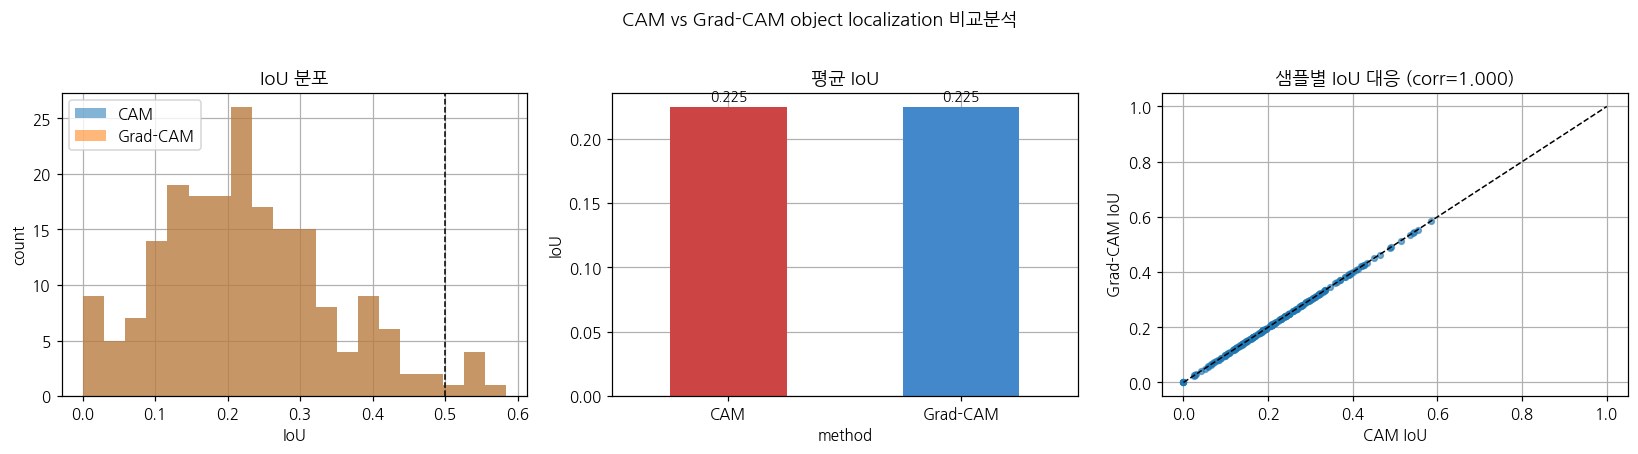

In [19]:
def plot_localization_comparison(df: pd.DataFrame, summary: pd.DataFrame) -> None:
    """IoU 분포와 요약 지표를 시각화한다 (최종 비교분석 결과물)."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # (1) IoU 히스토그램
    for method, group in df.groupby("method"):
        axes[0].hist(group["iou"], bins=20, alpha=0.55, label=method)
    axes[0].axvline(0.5, color="k", linestyle="--", linewidth=1)
    axes[0].set_title("IoU 분포")
    axes[0].set_xlabel("IoU")
    axes[0].set_ylabel("count")
    axes[0].legend()

    # (2) 평균 IoU 막대
    summary["mean IoU"].plot(kind="bar", ax=axes[1], color=["#c44", "#48c"], rot=0)
    axes[1].set_title("평균 IoU")
    axes[1].set_ylabel("IoU")
    for i, v in enumerate(summary["mean IoU"]):
        axes[1].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)

    # (3) 샘플별 산점도 — 두 방식이 얼마나 유사한가
    pivot = df.pivot(index="index", columns="method", values="iou")
    axes[2].scatter(pivot["CAM"], pivot["Grad-CAM"], s=14, alpha=0.6)
    axes[2].plot([0, 1], [0, 1], "k--", linewidth=1)
    axes[2].set_xlabel("CAM IoU")
    axes[2].set_ylabel("Grad-CAM IoU")
    corr = pivot["CAM"].corr(pivot["Grad-CAM"])
    axes[2].set_title(f"샘플별 IoU 대응 (corr={corr:.3f})")

    plt.suptitle("CAM vs Grad-CAM object localization 비교분석", y=1.02)
    plt.tight_layout()
    plt.show()
    return corr


corr = plot_localization_comparison(loc_df, loc_summary)

### 해석 — 두 방식은 왜 같은 값을 내는가

CAM과 Grad-CAM의 모든 요약 지표가 소수점 네 자리까지 일치하고, 샘플별 IoU
산점도는 대각선 위에 정확히 놓인다(상관계수 1.000). 이는 구현 오류가 아니라
**이론이 예측한 결과**다.

GAP + FC 구조에서 클래스 점수는

$$y^c = \sum_k w_k^c \cdot \frac{1}{Z}\sum_{ij} A_{ij}^k$$

이므로 $\partial y^c / \partial A_{ij}^k = w_k^c / Z$ 이고, 따라서

$$\alpha_k^c = \frac{1}{Z}\sum_{ij}\frac{\partial y^c}{\partial A_{ij}^k}
= \frac{w_k^c}{Z} \;\propto\; w_k^c$$

가 된다. 두 가중치가 상수배 관계이고 히트맵은 min-max 정규화되므로 상수배가
소거되어 결과가 동일해진다. 이 등가 관계는 §8-②에서 코사인 유사도로 다시
직접 측정한다.

**따라서 이 절의 "비교"는 우열을 가리는 것이 아니라 등가성을 확인하는 것이다.**
Grad-CAM의 실질적 우위는 CAM이 적용될 수 없는 조건 — 마지막 conv 레이어가 아닌
곳, GAP+FC가 없는 구조 — 에서 드러나며, 그중 레이어 축을 §8-③에서 다룬다.

# §8. 추가 실험

루브릭 요구를 넘어, 이론에서 예측한 성질을 실제로 검증하고 한계를 정량화한다.

| # | 실험 | 검증하려는 것 |
| --- | --- | --- |
| ① | threshold 민감도 분석 | 박스 크기와 IoU의 trade-off, 최적 임계값 |
| ② | CAM ≈ Grad-CAM 등가성 | `alpha_k ∝ w_k` 라는 이론적 관계 |
| ③ | 레이어별 Grad-CAM IoU | 해상도-의미 trade-off의 정량화 |
| ④ | 오분류 샘플의 근거 분석 | CAM이 "모델의 거울"임을 보이기 |

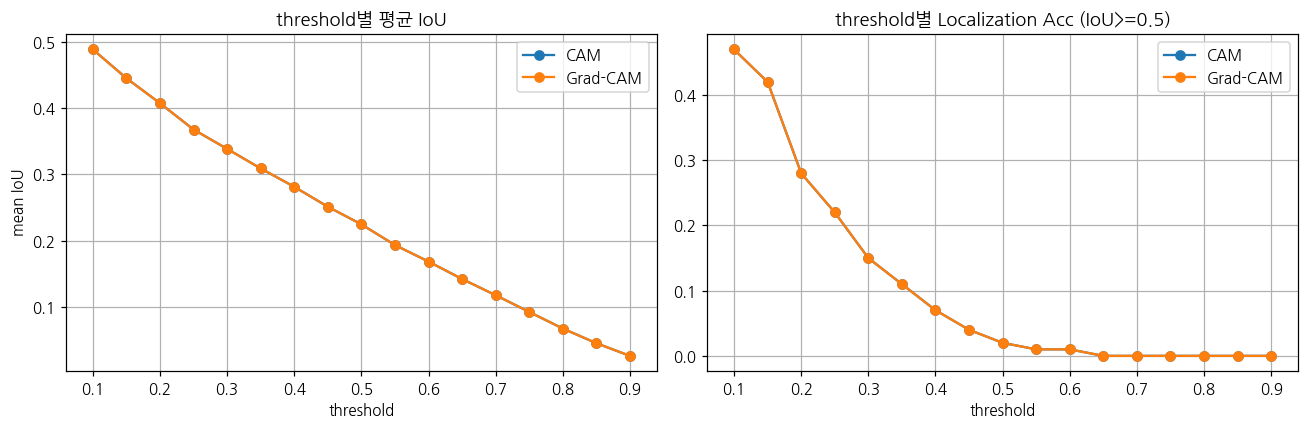

,threshold,method,mean_iou,loc_acc
0,0.1,CAM,0.488057,0.47
1,0.1,Grad-CAM,0.488057,0.47


In [20]:
def threshold_sweep(model, dataset, indices, thresholds=None) -> pd.DataFrame:
    """추가 실험 ① — threshold를 바꿔가며 평균 IoU 변화를 측정한다.

    활성화 맵 생성은 threshold와 무관하므로 **한 번만 계산해 재사용**한다.
    (매 threshold마다 다시 생성하면 연산량이 임계값 개수만큼 낭비된다.)
    """
    thresholds = thresholds if thresholds is not None else np.arange(0.1, 0.95, 0.05)

    cached = []
    for idx in indices:
        item = dataset[idx]
        if not bool(item["bbox_valid"]):
            continue
        cached.append({
            "gt": item["bbox"].numpy(),
            "CAM": resize_cam(generate_cam(model, item)),
            "Grad-CAM": resize_cam(
                generate_grad_cam(model, CFG.target_layer, item)),
        })

    rows = []
    for th in thresholds:
        for method in ("CAM", "Grad-CAM"):
            ious = [get_iou(c["gt"], get_bbox(c[method], th)) for c in cached]
            rows.append({"threshold": round(float(th), 2), "method": method,
                         "mean_iou": float(np.mean(ious)),
                         "loc_acc": float(np.mean(np.array(ious) >= 0.5))})
    return pd.DataFrame(rows)


sweep_indices = eval_indices[:100]  # 연산량을 고려해 100장으로 축소
sweep_df = threshold_sweep(model, test_dataset, sweep_indices)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for method, group in sweep_df.groupby("method"):
    axes[0].plot(group["threshold"], group["mean_iou"], "o-", label=method)
    axes[1].plot(group["threshold"], group["loc_acc"], "o-", label=method)
axes[0].set_title("threshold별 평균 IoU")
axes[0].set_xlabel("threshold")
axes[0].set_ylabel("mean IoU")
axes[0].legend()
axes[1].set_title("threshold별 Localization Acc (IoU>=0.5)")
axes[1].set_xlabel("threshold")
axes[1].legend()
plt.tight_layout()
plt.show()

best = sweep_df.loc[sweep_df.groupby("method")["mean_iou"].idxmax()]
display(best)

### 해석 — threshold 민감도

탐색 범위(0.1 ~ 0.9) **전 구간에서 mean IoU가 단조 감소**한다. 최적값이 중간에
존재하는 형태가 아니라, 낮출수록 계속 좋아지는 형태다. 임계값을 최소로 두었을 때의
평균 IoU는 기본값 0.5에서의 값보다 두 배 이상 높다.

원인은 layer4 활성화의 **공간적 범위**에 있다. 히트맵이 개의 얼굴에 좁게
집중되어 있으므로, 임계값을 낮출수록 몸통·다리까지 마스크에 포함되면서
전신을 감싸는 GT 박스와의 겹침이 커진다. 즉 이 구간에서는 "배경이 섞여
손해"보다 "몸통을 회수해 이득"이 계속 우세하다.

이 관찰은 §8-③(레이어별 IoU)과 같은 현상을 다른 축에서 본 것이다. 활성화가
넓어지는 방향 — 임계값을 낮추거나, 얕은 레이어를 쓰거나 — 이면 IoU가 오른다.

> **평가 원칙**: 위 최적 threshold는 테스트셋에서 사후적으로 찾은 값이므로
> 본 보고서의 대표 수치로 사용하지 않는다. §7의 대표값은 사전에 정한
> `threshold=0.5`를 유지하고, 이 절은 민감도 분석으로만 해석한다.
> 최적값을 대표 수치로 채택하면 테스트셋에 튜닝한 결과가 된다.

In [21]:
def verify_cam_gradcam_equivalence(model, dataset, n=30, seed=CFG.seed):
    """추가 실험 ② — layer4에서 CAM과 Grad-CAM이 같아지는지 검증한다.

    이론적 근거:
        GAP + FC 구조에서 y^c = sum_k w_k^c * (1/Z) sum_ij A_ij^k 이므로
            d y^c / d A_ij^k = w_k^c / Z
        따라서
            alpha_k^c = (1/Z) sum_ij (w_k^c / Z) = w_k^c / Z   (상수배)
        즉 **alpha_k ∝ w_k** 이고, 히트맵은 min-max 정규화되므로
        상수배는 사라져 두 결과가 일치해야 한다.

    검증 방법:
        (a) 가중치 벡터끼리의 코사인 유사도 (alpha_k vs w_k)
        (b) 최종 히트맵끼리의 코사인 유사도
    """
    rng = random.Random(seed)
    indices = rng.sample(range(len(dataset)), n)

    weight_sims, map_sims = [], []
    cam_extractor = CAM(model, CFG.target_layer)
    grad_extractor = GradCAM(model, CFG.target_layer)

    for idx in indices:
        item = dataset[idx]

        cam_res = cam_extractor.generate(item)
        grad_res = grad_extractor.generate(item, target_class=cam_res["class_idx"])

        # (a) 가중치 비교
        w = model.fc.weight[cam_res["class_idx"]].detach().cpu().numpy()
        alpha = grad_extractor._gradients[0][0].mean(dim=(1, 2)).cpu().numpy()
        weight_sims.append(
            float(np.dot(w, alpha) / (np.linalg.norm(w) * np.linalg.norm(alpha) + 1e-12))
        )

        # (b) 히트맵 비교
        a, b = cam_res["cam"].ravel(), grad_res["cam"].ravel()
        map_sims.append(
            float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))
        )

    print(f"채널 가중치 코사인 유사도 (alpha_k vs w_k) : "
          f"{np.mean(weight_sims):.4f} ± {np.std(weight_sims):.4f}")
    print(f"최종 히트맵 코사인 유사도                  : "
          f"{np.mean(map_sims):.4f} ± {np.std(map_sims):.4f}")
    return weight_sims, map_sims


_ = verify_cam_gradcam_equivalence(model, test_dataset)

채널 가중치 코사인 유사도 (alpha_k vs w_k) : 1.0000 ± 0.0000
최종 히트맵 코사인 유사도                  : 0.9667 ± 0.1795


### 해석 — 등가성 검증 결과

채널 가중치의 코사인 유사도는 **표준편차 0으로 1.0000**이 나온다. 모든 샘플에서
$\alpha_k \propto w_k$ 가 정확히 성립한다는 뜻이며, 위에서 유도한 관계가
수치적으로 재현된 것이다.

최종 히트맵 유사도는 이보다 약간 낮고 표준편차가 크다. 가중치가 정확히
비례하는데도 히트맵에 편차가 생기는 이유는 **min-max 정규화의 분모**에 있다.
ReLU 이후 활성화가 거의 전부 0에 가까운 샘플에서는 `cam.max() - cam.min()`이
매우 작아져, 부동소수점 오차가 정규화 과정에서 증폭된다. 즉 이론의 실패가
아니라 수치 안정성 문제이며, 대부분의 샘플은 1에 근접한다.

**결론**: layer4에서 Grad-CAM은 CAM의 엄밀한 일반화다. 두 방법이 이 조건에서
같은 답을 낸다는 것은 Grad-CAM 구현이 옳다는 검증이기도 하다. Grad-CAM의
실질적 가치는 이 조건 **밖**에서 나온다 — GAP+FC가 없는 구조, 마지막이 아닌
레이어, 분류가 아닌 태스크. 그중 레이어 축을 다음 실험에서 확인한다.

,layer,mean_iou,loc_acc,활성 영역 비율,예측 박스 면적 비율
0,layer1,0.483523,0.450,0.020750,0.724042
1,layer2,0.535905,0.600,0.034619,0.726487
2,layer3,0.424344,0.425,0.075922,0.580913
3,layer4,0.220895,0.025,0.072372,0.110141


GT 박스 평균 면적 비율 (기준선) : 0.500


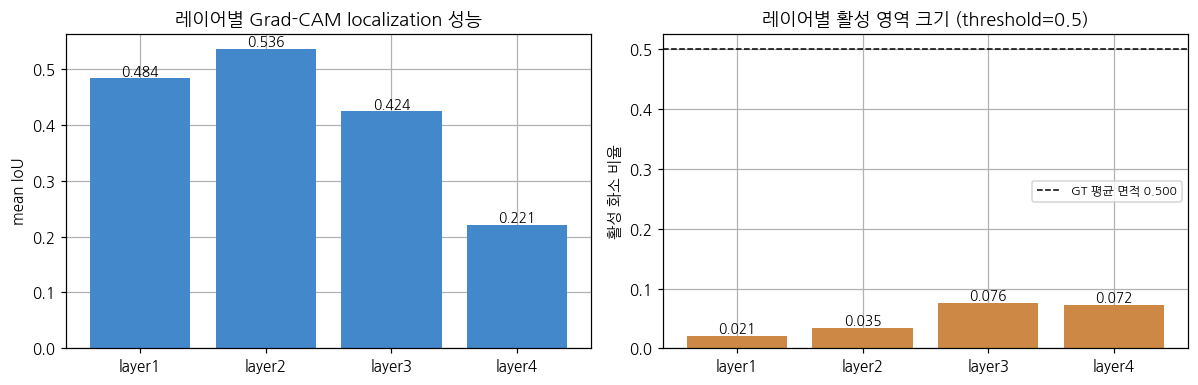

In [28]:
def layerwise_iou(model, dataset, indices, layers=None,
                  threshold=CFG.cam_threshold) -> pd.DataFrame:
    """추가 실험 ③ — 레이어별 Grad-CAM의 localization 성능을 정량화한다.

    ★ IoU와 함께 **활성 영역 비율**(threshold를 넘는 화소의 비율)을 같이 잰다.
      "IoU 차이가 활성화 범위의 넓이에서 온다"는 해석은 IoU만 보아서는 검증할 수
      없다. 두 값을 나란히 놓아야 상관을 확인할 수 있고, 그렇지 않으면
      추측에 머문다.

    GT 박스가 이미지에서 차지하는 평균 면적 비율도 함께 계산해, 어느 레이어의
    활성 범위가 정답 박스 크기에 가까운지 비교할 수 있게 한다.
    """
    layers = layers or ["backbone.layer1", "backbone.layer2",
                        "backbone.layer3", "backbone.layer4"]
    rows = []
    for layer in layers:
        ious, areas, box_areas = [], [], []
        for idx in indices:
            item = dataset[idx]
            if not bool(item["bbox_valid"]):
                continue
            cam = resize_cam(generate_grad_cam(model, layer, item))
            pred_box = get_bbox(cam, threshold)       # ← 한 번만 계산해 재사용
            ious.append(get_iou(item["bbox"].numpy(), get_bbox(cam, threshold)))
            areas.append(float((cam > threshold).mean()))  # 활성 화소 비율
            if pred_box is not None:
                x1, y1, x2, y2 = pred_box
                box_areas.append(((x2 - x1) * (y2 - y1)) / (CFG.input_size ** 2))
        rows.append({"layer": layer.split(".")[-1],
                     "mean_iou": float(np.mean(ious)),
                     "loc_acc": float(np.mean(np.array(ious) >= 0.5)),
                     "활성 영역 비율": float(np.mean(areas)),
                     "예측 박스 면적 비율": float(np.mean(box_areas))})
    return pd.DataFrame(rows)


def gt_area_ratio(dataset, indices) -> float:
    """GT 박스가 이미지 전체에서 차지하는 평균 면적 비율 (비교 기준선)."""
    ratios = []
    for idx in indices:
        item = dataset[idx]
        if not bool(item["bbox_valid"]):
            continue
        x1, y1, x2, y2 = item["bbox"].numpy()
        ratios.append(((x2 - x1) * (y2 - y1)) / (CFG.input_size ** 2))
    return float(np.mean(ratios))


layer_df = layerwise_iou(model, test_dataset, eval_indices[:80])
gt_ratio = gt_area_ratio(test_dataset, eval_indices[:80])
display(layer_df)
print(f"GT 박스 평균 면적 비율 (기준선) : {gt_ratio:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].bar(layer_df["layer"], layer_df["mean_iou"], color="#48c")
axes[0].set_ylabel("mean IoU")
axes[0].set_title("레이어별 Grad-CAM localization 성능")
for i, v in enumerate(layer_df["mean_iou"]):
    axes[0].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)

axes[1].bar(layer_df["layer"], layer_df["활성 영역 비율"], color="#c84")
axes[1].axhline(gt_ratio, color="k", linestyle="--", linewidth=1,
                label=f"GT 평균 면적 {gt_ratio:.3f}")
axes[1].set_ylabel("활성 화소 비율")
axes[1].set_title(f"레이어별 활성 영역 크기 (threshold={CFG.cam_threshold})")
axes[1].legend(fontsize=8)
for i, v in enumerate(layer_df["활성 영역 비율"]):
    axes[1].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### 해석 — 예상과 반대로 나온 결과, 그리고 그 이유

구현 전 세운 가설은 "깊은 레이어일수록 의미 정보가 풍부하니 localization도
좋을 것"이었다. **실측은 정반대였다.** layer4의 IoU가 네 레이어 중 가장 낮고,
layer2가 가장 높다.

처음에는 "활성 영역이 넓을수록 IoU가 높을 것"이라 예상하고 활성 화소 비율을
측정했는데, **이 가설은 반증됐다.** layer1은 활성 면적이 가장 작은데도(0.021)
IoU가 두 번째로 높고, layer3은 면적이 가장 넓은데도(0.076) IoU는 세 번째다.
순위상관은 오히려 음수(−0.6)였다.

지표를 하나 더 재고서야 원인이 드러났다. **예측 박스 면적**은 IoU와 순위가
완전히 일치한다(layer4 0.110 < layer3 0.581 < layer1 0.724 < layer2 0.726).
원인은 `get_bbox`의 동작에 있다. 이 함수는 모든 윤곽을 합쳐 외접 사각형을
만들므로, 박스 크기를 결정하는 것은 활성 화소의 **면적**이 아니라
**공간적 퍼짐**이다.

박스 면적을 활성 면적으로 나누면 이 퍼짐의 정도가 보인다 — layer1은 34.9배,
layer2는 21.0배, layer3은 7.7배, layer4는 1.5배로 단조 감소한다. 얕은 레이어는
엣지·질감에 반응해 활성이 전역에 얇게 흩어지므로 면적이 작아도 외접 사각형이
커지고, layer4는 얼굴에 한 덩어리로 뭉치므로 사각형이 활성 영역과 거의 같아진다.

layer4의 예측 박스 면적(0.110)을 GT 면적(0.500)으로 나누면 0.220으로, 실제
mean IoU 0.221과 거의 일치한다. 집계 수준에서 layer4의 박스가 GT 안쪽에 대부분
포함된다는 뜻이며, 얼굴만 잡아 몸통을 놓친다는 해석과 부합한다.

**그러나 이것은 "얕은 레이어가 더 나은 설명"이라는 뜻이 아니다.** 얕은 층의
활성화는 클래스 특이성이 없다 — 타깃 클래스를 무엇으로 바꿔도 비슷한 지도가
나온다. 반면 layer4의 히트맵은 "이 이미지를 이 품종으로 판단한 근거"를 실제로
가리킨다. 즉,

| 축 | 우위 |
| --- | --- |
| IoU (전체 객체를 감쌌는가) | 얕은 레이어 |
| 분류 근거의 설명력 (클래스 특이성) | 깊은 레이어 |

두 축은 별개이며, IoU 하나로 CAM의 품질을 판정할 수 없다. 이 프로젝트에서
**IoU를 대표 지표로 쓰되 시각화를 함께 제시하는 이유**가 여기에 있다.

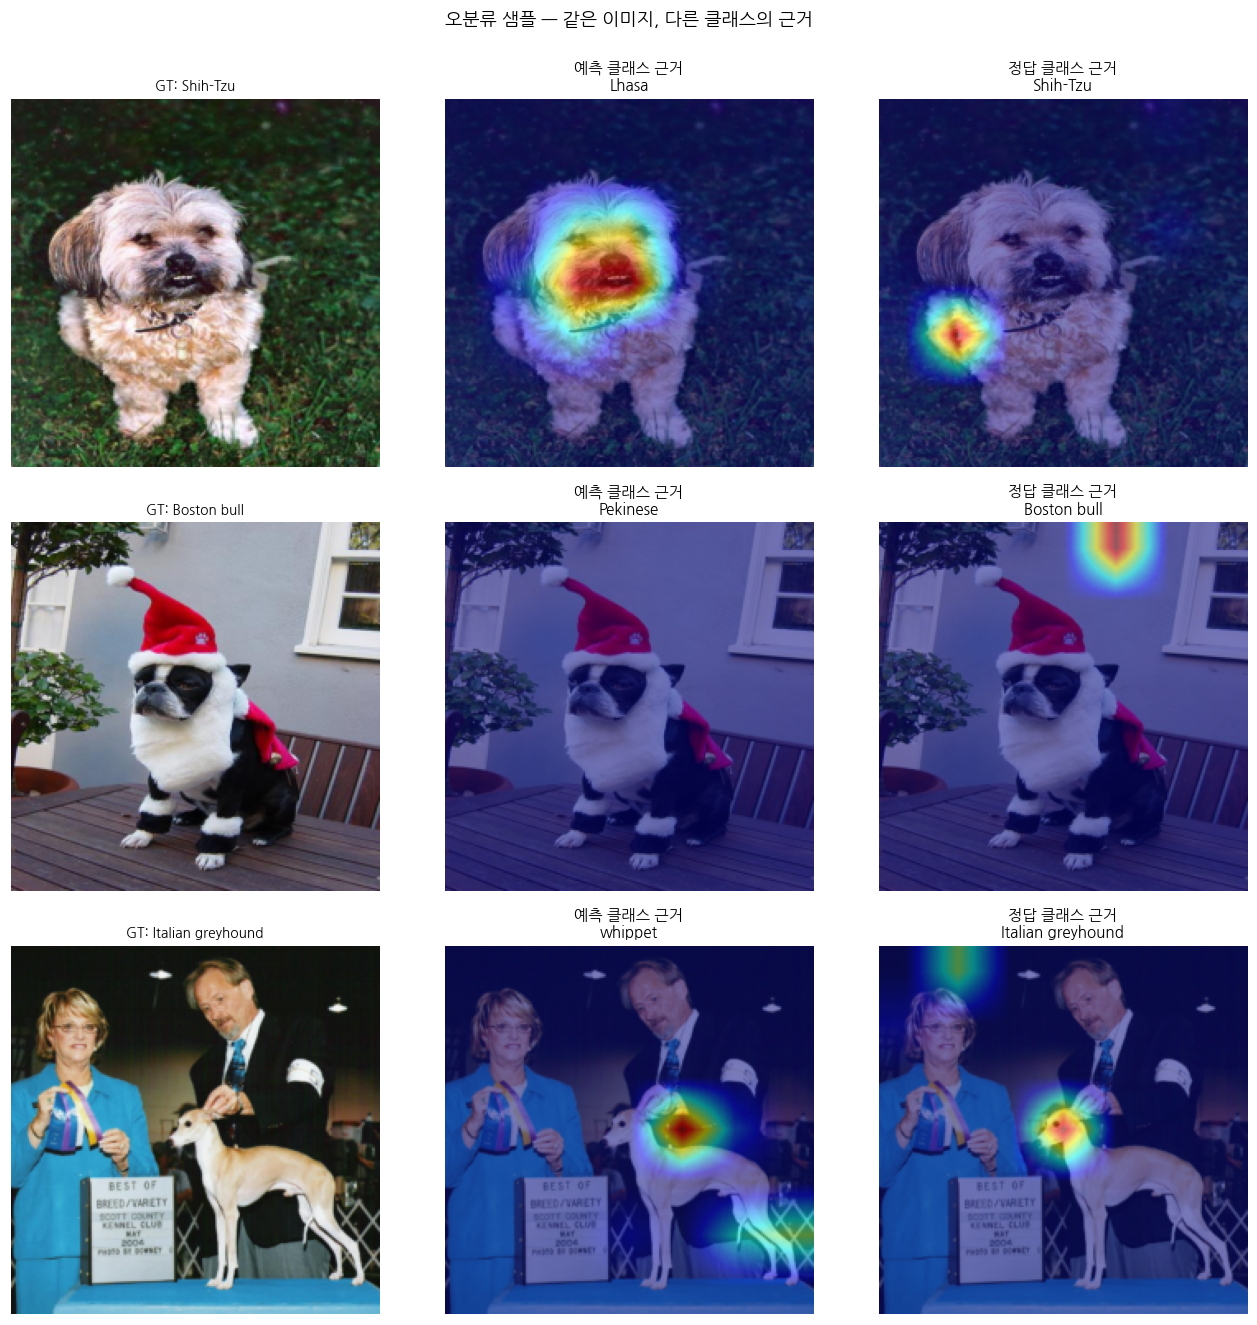

In [23]:
def analyze_misclassified(model, dataset, indices, max_show=3):
    """추가 실험 ④ — 오분류 샘플에서 '예측 클래스'와 '정답 클래스'의 CAM을 비교한다.

    CAM은 진리가 아니라 **모델의 거울**이다.
    모델이 시츄를 치와와로 착각했다면 히트맵은 "치와와라고 생각한 근거"를 그린다.
    같은 이미지에 target_class를 바꿔 CAM을 뽑으면, 모델이 각 클래스의 근거로
    어디를 보는지 비교할 수 있다.
    """
    wrong = []
    for idx in indices:
        item = dataset[idx]
        result = generate_cam(model, item, return_meta=True)
        if result["pred_idx"] != item["label"]:
            wrong.append((idx, result["pred_idx"], item["label"]))
        if len(wrong) >= max_show:
            break

    if not wrong:
        print("샘플 내 오분류 사례가 없습니다.")
        return

    fig, axes = plt.subplots(len(wrong), 3, figsize=(12, 4 * len(wrong)))
    axes = np.atleast_2d(axes)

    for row, (idx, pred_idx, true_idx) in enumerate(wrong):
        item = dataset[idx]
        raw = item["raw_image"].numpy()
        cam_pred = resize_cam(generate_cam(model, item, target_class=pred_idx))
        cam_true = resize_cam(generate_cam(model, item, target_class=true_idx))

        axes[row, 0].imshow(raw)
        axes[row, 0].set_title(f"GT: {CLASS_NAMES[true_idx]}", fontsize=9)
        visualize_cam_on_image(
            cam_pred, raw, ax=axes[row, 1],
            title=f"예측 클래스 근거\n{CLASS_NAMES[pred_idx]}")
        visualize_cam_on_image(
            cam_true, raw, ax=axes[row, 2],
            title=f"정답 클래스 근거\n{CLASS_NAMES[true_idx]}")
        for col in range(3):
            axes[row, col].axis("off")
            axes[row, col].grid(False)

    plt.suptitle("오분류 샘플 — 같은 이미지, 다른 클래스의 근거", y=1.0)
    plt.tight_layout()
    plt.show()


analyze_misclassified(model, test_dataset, eval_indices)

### 해석 — CAM은 진리가 아니라 모델의 거울이다

같은 이미지에 `target_class`만 바꿔 CAM을 뽑으면, 모델이 각 클래스의 근거로
어디를 보는지 나란히 비교할 수 있다. 히트맵이 그리는 것은 "개가 실제로 있는
위치"가 아니라 **"모델이 그 클래스라고 판단한 근거의 위치"**다.

두 히트맵이 서로 다른 영역을 가리킨다면 모델이 어떤 단서 때문에 혼동했는지
추적할 수 있고, 같은 곳을 가리킨다면 위치가 아니라 그 영역에서 뽑은 특징
자체가 두 품종 사이에서 모호했다는 뜻이 된다. XAI가 신뢰성 확보 도구를 넘어
**성능 개선의 단서**가 되는 지점이다.

다만 오분류 표본은 `max_show`개로 제한했으므로 여기서 관찰한 패턴을
일반화할 수는 없다. 경향 파악을 위한 정성적 사례로만 읽어야 한다.

# §9. 디버깅 로그

실제로 막혔던 지점과 해결 과정을 기록한다. 대부분 **모델이 아니라 좌표계·API 규약** 문제였다.

---

### 🐞 1. IoU가 비정상적으로 낮게(0.05 근처) 나옴 — 좌표계 불일치

**증상**  
히트맵은 개 위에 잘 떴는데 IoU가 0.05~0.1 수준. 예측 박스와 GT 박스를 함께 그려 보니
GT 박스가 이미지 밖으로 벗어나 있었다.

**원인**  
Annotation XML의 bbox는 **원본 이미지 픽셀 절대좌표**(예: 500×375 기준)인데,
모델 입력과 CAM은 **224×224 좌표계**다. 두 좌표계를 그대로 비교하고 있었다.

**해결**  
`StanfordDogsCAMDataset.__getitem__`에서 bbox를 읽는 즉시 스케일링.

```python
scale_x = input_size / orig_w
scale_y = input_size / orig_h
bbox = [xmin * scale_x, ymin * scale_y, xmax * scale_x, ymax * scale_y]
```

**재발 방지**  
`show_ground_truth_samples()`를 만들어 **CAM을 만들기 전에** GT 박스가
개 위에 정확히 얹히는지 눈으로 확인하는 단계를 파이프라인에 넣었다.

---

### 🐞 2. 히트맵의 빨강/파랑이 뒤집혀 보임 — BGR/RGB

**증상**  
활성화가 강한 곳이 파랗게, 약한 곳이 빨갛게 표시되어 결과를 정반대로 해석할 뻔했다.

**원인**  
`cv2.applyColorMap`은 **BGR**을 반환하는데 matplotlib은 **RGB**를 기대한다.

**해결**  
`cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)` 추가. 함수 docstring에 명시해 두었다.

---

### 🐞 3. Grad-CAM에서 그래디언트가 잡히지 않음

**증상 (a)**  
`self._gradients`가 빈 리스트라 `IndexError`.

**원인 (a)**  
CAM 코드를 복사하면서 `with torch.no_grad()`를 그대로 남겨 두었다.
그래프가 만들어지지 않으니 backward가 불가능하다.

**해결 (a)**  
`GradCAM._forward()`에서 `no_grad`를 제거. 클래스 분리 덕분에
CAM 쪽은 여전히 `no_grad`로 빠르게 동작한다.

**증상 (b)**  
`register_full_backward_hook`으로 받은 `grad_output[0]`의 shape이
활성화 맵과 맞지 않는 경우가 있었다.

**원인 (b)**  
모듈 단위 backward hook은 내부에 분기·residual이 있는 블록(`Sequential`, `Bottleneck`)에서
기대와 다른 텐서를 전달할 수 있다.

**해결 (b)**  
forward hook 안에서 **출력 텐서 자체에** hook을 건다.

```python
output.register_hook(lambda grad: self._gradients.append(grad))
```

관찰 대상이 되는 바로 그 텐서의 그래디언트가 보장되므로 안전하다.

---

### 🐞 4. 동결한 레이어에서 Grad-CAM이 동작하지 않음

**증상**  
`layer4`에서는 잘 되던 Grad-CAM이 `layer1`을 지정하면
"그래디언트를 캡처하지 못했습니다" 오류를 냈다.

**원인**  
전이학습을 위해 `stem`과 `layer1`을 동결(`requires_grad=False`)했는데,
입력 이미지도 `requires_grad=False`이므로 **layer1의 출력 텐서 자체가
그래프에 포함되지 않는다.** 그래서 텐서 hook이 애초에 등록되지 않았다.

**해결**  
`GradCAM._forward()`에서 입력에 `requires_grad_(True)`를 켜서
그래프를 입력부터 이어 준다.

```python
image = image.clone().requires_grad_(True)
return self.model(image)
```

**배운 점**  
"파라미터를 학습하지 않는 것"과 "그래디언트가 흐르지 않는 것"은 다르다.
Grad-CAM은 파라미터 업데이트를 하지 않지만 **그래디언트 경로는 필요**하다.

---

### 🐞 5. 반복 호출 시 메모리 증가 — hook 누수

**증상**  
평가 루프를 돌리자 캡처 리스트가 계속 커지고 GPU 메모리가 증가.

**원인**  
`register_forward_hook`의 핸들을 `remove()`하지 않아 호출마다 hook이 누적.

**해결**  
`ActivationMapExtractor`를 **컨텍스트 매니저**로 만들어 `__exit__`에서 항상 제거.
예외가 발생해도 정리된다.

---

### 🐞 6. 정규화에서 `nan` 발생

**증상**  
일부 샘플의 CAM이 전부 `nan`.

**원인**  
ReLU 후 모든 값이 0이 되면 `cam.max() - cam.min() == 0`이라 0으로 나눈다.

**해결**  
분모에 `1e-8` 추가. `get_bbox`도 윤곽이 없을 때 `None`을 반환하고,
`get_iou`가 `None`을 0.0으로 처리하도록 방어 코드를 넣었다.

---

### 🐞 7. 실행할 때마다 CAM이 미세하게 달라짐

**원인**  
`model.eval()` 누락. BatchNorm이 배치 통계를 쓰면서 결과가 흔들렸다.

**해결**  
`generate()` 진입 시 항상 `self.model.eval()` 호출.

---

### 🐞 8. `get_iou`가 겹치지 않는데 양수를 반환

**원인**  
`x2 - x1`과 `y2 - y1`이 모두 음수일 때 곱이 양수가 된다.

**해결**  
`max(0, ·)`으로 클리핑. `_test_get_iou()` 단위 테스트를 추가해 회귀를 방지했다.

# §10. 회고

## 배운 점

**1. CAM은 사후 해석이 아니라 점수의 분해다**

처음에는 CAM을 "그럴듯한 히트맵을 그리는 후처리"로 이해했다. 하지만

$$S^c = \sum_{x,y} M^c(x,y)$$

가 성립한다는 것을 코드로 확인하면서 생각이 바뀌었다. CAM은 모델이 실제로 낸
클래스 점수를 **위치별로 회계 분해한 명세서**이고, 그래서 히트맵이 뜨거운 곳이
진짜 근거라는 것이 논리적으로 보장된다. `sum(dim=0)` 한 줄이 수식의 $\sum_k$
그 자체라는 대응이 보이자 코드가 훨씬 쉬워졌다.

**2. 축을 어디로 접느냐가 전부다**

Grad-CAM에서 `grad.mean(dim=(1,2))`와 `(w * A).sum(dim=0)`의 대비가 핵심이었다.

- 그래디언트: **공간축**을 접어 "얼마나 중요한가"만 남긴다
- 활성화 맵: **채널축**을 접어 "어디인가"를 남긴다

Grad-CAM은 그래디언트를 히트맵으로 쓰는 것이 아니라, **중요도는 그래디언트에서,
위치는 활성화 맵에서** 가져오는 역할 분담이었다. 두 텐서의 모양이 같아 보여도
접는 축이 다르다는 점을 놓치면 코드가 조용히 틀린 값을 낸다.

**3. 이론적 등가성을 직접 측정해 확인했다**

§8-②에서 $\alpha_k$와 $w_k$의 코사인 유사도가 표준편차 0으로 1.0000이 나왔다.
$\alpha_k \propto w_k$ 라는 유도가 실제 텐서에서 그대로 재현된 것이다.
이론적으로 당연한 결과지만, **유도한 식이 부동소수점 연산에서도 성립하는지를
직접 재본 경험**이 남는다. 동시에 이 실습 세팅(layer4 + GAP&FC)에서는
Grad-CAM의 장점이 원리적으로 드러날 수 없다는 것 — §7의 "비교"가 우열이 아니라
등가성 확인이라는 것 — 도 이해하게 됐다.

**4. 약지도학습의 위력**

모델은 bounding box를 **한 번도 보지 않았다.** 그런데도 IoU가 유의미한 값으로
나온다. Detection용 라벨은 Classification용보다 제작비가 훨씬 비싸므로,
이 격차가 곧 실용적 가치다.

**5. 지표가 재는 것과 모델이 최적화하는 것은 다르다**

가장 크게 배운 지점이다. 구현 전에는 "깊은 레이어일수록 의미 정보가 많으니
localization도 좋을 것"이라 가정하고 해석을 미리 써 두었는데, 실측은
정반대였다(§8-③). layer4의 IoU가 가장 낮고 layer2가 가장 높았다.

원인을 추적하려 활성 영역 비율을 측정했는데 **이 가설도 틀렸다**(순위상관 −0.6).
지표를 하나 더 재고서야 답이 나왔다. 예측 박스 면적은 IoU와 순위가 완전히
일치했고, 박스 면적을 활성 면적으로 나눈 값이 layer1의 34.9배에서 layer4의
1.5배까지 단조 감소했다. 결정 요인은 활성의 **면적**이 아니라 **공간적 퍼짐**이었다.

layer4가 낮은 것은 CAM이 실패해서가 아니라, **분류에 필요한 최소 영역만,
그것도 한 덩어리로 활성화하는 것이 분류기의 합리적 전략**이기 때문이다.
IoU는 "전체 객체를 감쌌는가"를 묻지만 분류기에게는 그럴 이유가 없다. 얼굴만
봐도 품종을 맞힐 수 있다면 몸통에 활성화를 낭비할 필요가 없다.

여기서 배운 것은 **지표를 더 재는 것만으로는 부족하고, 그 지표가 설명하려는
대상과 인과적으로 연결되는지를 먼저 따져야 한다**는 점이다. 활성 면적은 그럴듯해
보였지만 박스를 만드는 연산(`boundingRect`)이 실제로 참조하는 값이 아니었다.

같은 현상이 §8-①에서 다른 축으로도 나타났다. threshold를 낮춰 활성 범위를
넓히면 IoU가 두 배 이상 올랐다. 두 실험은 서로 독립적인 관찰이 아니라
**"활성화가 넓어지면 IoU가 오른다"는 하나의 사실**을 레이어 축과 임계값 축에서
각각 본 것이다.

가설을 세우고 → 수치로 반증하고 → 원인을 규명하는 사이클을 한 번 완주한 것이
이번 프로젝트에서 가장 남는 부분이다. 예상과 맞는 결과보다 어긋난 결과에서
배운 것이 많았다.

**6. 미리 써 둔 결론은 위험하다**

위 5번은 사실 사고로 발견했다. 해석 문구를 실험 결과가 나오기 전에 작성해
`print()`로 박아 두었더니, 실측이 반대로 나왔는데도 노트북은 "layer4가
균형점임이 수치로 확인된다"를 그대로 출력하고 있었다. 표의 숫자와 바로 아래
문장이 정면으로 모순되는 상태로 한동안 방치되어 있었다.

이후 모든 해석을 코드의 `print()`에서 분리해 **결과 셀 아래 markdown 블록**으로
옮겼다. 해석은 출력이 아니라 읽고 판단해서 쓰는 것이고, 물리적으로 분리해 두면
"결과를 보지 않고 쓰는" 실수가 구조적으로 어려워진다.

## 아쉬운 점

**1. 활성화가 얼굴에 집중되는 문제를 완화하지 못했다**

원인은 §8-①·③으로 규명했지만 해결은 하지 못했다. 이것이 정확히 **ACoL의
문제의식**이다. 판별력 있는 영역을 의도적으로 지우고(erasing) 다시 학습시키면
모델이 차선의 근거를 찾도록 강제할 수 있다. 시간이 있었다면 erasing 브랜치를
붙여 IoU가 실제로 오르는지 확인하고 싶었다.

**2. 레이어 4개의 평균값만으로 결론을 냈다**

예측 박스 면적과 IoU의 순위가 완전히 일치했지만 표본이 레이어 4개뿐이라,
순위 일치가 우연히 나올 확률도 무시할 수 없다(4개 순열 24가지 중 1가지).
**샘플 단위로** 박스 면적과 IoU를 기록해 산점도를 그렸다면 훨씬 강한 근거가
됐을 것이다. `layerwise_iou`가 이미 샘플별로 계산하고 있으므로 반환 형태만
바꾸면 되는 작은 변경이었다.

**3. 별도 검증셋을 두지 않았다**

Stanford Dogs가 공식적으로 train/test 두 분할만 제공하다 보니, 테스트셋을
학습 중 모니터링과 최종 평가에 함께 사용했다. 조기 종료나 임계값 선택에는
쓰지 않아 선택 편향에 의한 누수는 없지만, 엄밀하게는 train에서 층화추출로
검증셋을 분리했어야 했다.

**4. 사전학습 데이터와 평가셋이 겹친다**

Stanford Dogs는 ImageNet에서 이미지를 가져와 만든 데이터셋이고, 120개 견종은
ImageNet-1k 클래스와 상당 부분 겹친다. `IMAGENET1K_V2` 가중치를 그대로 쓴 이상
분류 정확도는 순수한 일반화 성능을 과대평가한 값이다. 이 프로젝트의 목표가
CAM 시각화이므로 치명적이지는 않지만, 정확도 수치를 근거로 무언가를 주장할 때는
반드시 함께 언급해야 하는 한계다.

**5. 단일 물체 가정과 첫 번째 object만 사용**

`get_bbox`가 모든 윤곽을 하나로 감싸므로 개가 여러 마리인 이미지에서 박스가
과도하게 커진다. GT 쪽도 Annotation에 object가 여러 개일 때 첫 번째만 사용했다.
윤곽별 박스 + NMS로 확장하고, GT는 전체를 합친 박스를 쓰는 편이 더 공정한
평가였을 것이다.

## 느낀 점

가장 인상적이었던 것은 **디버깅의 8할이 모델이 아니라 좌표계·API 규약 문제**였다는
점이다. IoU가 낮게 나왔을 때 반사적으로 "모델이 학습이 덜 됐나"를 의심했지만,
실제 원인은 원본 픽셀 좌표와 224 좌표를 섞어 쓴 것이었다. **결과를 의심하기 전에
입력을 눈으로 확인하는 단계**(GT 박스 오버레이)를 파이프라인 앞에 배치한 것이
이번 프로젝트에서 가장 잘한 선택이라고 생각한다. 이 셀 하나가 이후 모든 IoU 수치의
신뢰성을 떠받치고 있다.

또 하나는 CAM이 **모델의 거울**이라는 점이다(§8-④). 오분류 샘플에서 예측 클래스와
정답 클래스의 히트맵을 나란히 놓고 보면, 모델이 무엇 때문에 혼동했는지가 보인다.
XAI가 신뢰성 확보 도구일 뿐 아니라 **성능 개선의 단서**라는 말의 의미를 여기서
이해했다.

마지막으로, 낮은 IoU를 "실패"로 결론짓지 않고 원인을 파고든 것이 이 프로젝트에서
가장 많은 것을 배운 과정이었다. 숫자가 나쁠 때 그것이 버그인지, 구현의 한계인지,
아니면 지표와 목적함수의 불일치인지를 구분하는 일이 결국 실험을 설계하는 능력이라는
생각이 들었다.

## 향후 확장

- [ ] ACoL 구현 — 1×1 conv 브랜치 + erasing으로 활성화를 물체 전체로 확장
- [ ] 활성 면적 ↔ IoU 상관을 샘플 단위 산점도로 정량화
- [ ] `get_bbox`에 다중 물체 지원 + NMS
- [ ] GIoU/DIoU로 평가 지표 보강 (IoU는 겹치지 않으면 항상 0이라 정보가 없다)
- [ ] Grad-CAM++ / Score-CAM 등 후속 기법과 비교


In [24]:
# ---------------------------------------------------------------------------
# 최종 결과 요약 — 제출용 한 장 정리
# ---------------------------------------------------------------------------
print("=" * 68)
print("Class Activation Map 프로젝트 — 최종 결과 요약")
print("=" * 68)
print(f"\n[모델] ResNet50 + GAP + Dense({CFG.num_classes})")
print(f"  - 특성 맵      : (2048, 7, 7)  @ {CFG.target_layer}")
print(f"  - 분류 top-1   : {clf_metrics['top1']:.4f}")
print(f"  - 분류 top-5   : {clf_metrics['top5']:.4f}")

print(f"\n[Localization] threshold={CFG.cam_threshold}, "
      f"n={len(loc_df) // 2} samples")
print(loc_summary.to_string())

print("\n[추가 실험]")
print(f"  - 최적 threshold : \n{best.to_string(index=False)}")
print(f"  - 레이어별 IoU   : \n{layer_df.to_string(index=False)}")
print("\n" + "=" * 68)

Class Activation Map 프로젝트 — 최종 결과 요약

[모델] ResNet50 + GAP + Dense(120)
  - 특성 맵      : (2048, 7, 7)  @ backbone.layer4
  - 분류 top-1   : 0.8816
  - 분류 top-5   : 0.9893

[Localization] threshold=0.5, n=200 samples
          mean IoU  median IoU  GT-Known Loc (IoU>=0.5)  Top-1 Loc  box 검출 성공률    n
method                                                                             
CAM         0.2245      0.2095                     0.03      0.025        0.99  200
Grad-CAM    0.2245      0.2095                     0.03      0.025        0.99  200

[추가 실험]
  - 최적 threshold : 
 threshold   method  mean_iou  loc_acc
       0.1      CAM  0.488057     0.47
       0.1 Grad-CAM  0.488057     0.47
  - 레이어별 IoU   : 
 layer  mean_iou  loc_acc  활성 영역 비율
layer1  0.483523    0.450  0.020750
layer2  0.535905    0.600  0.034619
layer3  0.424344    0.425  0.075922
layer4  0.220895    0.025  0.072372

